# Predicting Hourly Bike-Sharing Demand in Seoul

This notebook is the consolidated write-up of an end-to-end data science project I completed on the Seoul bike-sharing system. The work spans data collection, data wrangling, exploratory analysis with SQL and ggplot2, and linear regression modelling — both a baseline and a refined version with polynomial terms, interaction terms, and regularization.

The core question I set out to answer: **can I predict the hourly count of bikes rented in Seoul from weather and date/time information?**

To support that, I also collected contextual information about other bike-sharing systems worldwide and live weather data from the OpenWeather API so the model could later be applied to comparable cities.

Anatoli Ignatov <br>
2025-05-15

## Part 1 — Collecting background data by web-scraping a Wikipedia page

Before doing any analysis I needed background context on bike-sharing systems worldwide — their location, launch date, fleet size, and so on. Wikipedia maintains a comprehensive list at <https://en.wikipedia.org/wiki/List_of_bicycle-sharing_systems>, so I used the `rvest` package to scrape that page, convert the relevant HTML table into a data frame, and save it as a CSV for later wrangling.

I loaded `rvest` together with `tidyverse`:

In [154]:
# Check if need to install rvest` library
library(rvest)
library(tidyverse)

I read the root HTML node and pulled out all `<table>` nodes on the page. There are several tables under the root; the bike-sharing systems table is the first one (`table_nodes[[1]]`).

In [2]:
url <- "https://en.wikipedia.org/wiki/List_of_bicycle-sharing_systems"
# Get the root HTML node by calling the `read_html()` method with URL
root_node <- read_html(url)
table_nodes <- html_nodes(root_node, "table")

I converted the chosen HTML table into a data frame with `html_table()`, passing `fill = TRUE` to handle any empty rows or columns.

In [3]:
# Convert the bike-sharing system table into a dataframe
bike_df <- as.data.frame(html_table(table_nodes[[1]], fill = TRUE))

I ran a quick summary to confirm the structure of the scraped data frame:

In [4]:
# Summarize the dataframe
summary(bike_df)

   Country            Country          City / Region          Name          
 Length:898         Length:898         Length:898         Length:898        
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
    System            Operator           Launched         Discontinued      
 Length:898         Length:898         Length:898         Length:898        
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  

Finally I exported the result as `raw_bike_sharing_systems.csv` so that the data-wrangling stage could pick it up later.

In [5]:
# Export the dataframe into a csv file
write.csv(bike_df,"raw_bike_sharing_systems.csv", row.names = FALSE)

## Part 2 — Collecting live weather data with the OpenWeather API

Next I needed real, current weather data. I used the OpenWeather API, which provides current weather and 5-day forecasts for any city via simple HTTP requests. I registered for a free API key, then drove the API from R using the `httr` package.

I started by loading `httr`:

In [155]:
library(httr)

Warning message:
"package 'httr' was built under R version 4.5.3"


The base URL for current weather is `https://api.openweathermap.org/data/2.5/weather`. I stored it in a variable:

In [7]:
# URL for Current Weather API
current_weather_url <- 'https://api.openweathermap.org/data/2.5/weather'

I built a query list containing the city name, my API key, and the unit system (metric):

In [8]:
# need to be replaced by your real API key
my_api_key <- "some_api_key"
# Input `q` is the city name
# Input `appid` is my API KEY, 
# Input `units` are preferred units such as Metric or Imperial
current_query <- list(q = "Seoul", appid = my_api_key, units="metric")

I issued the HTTP GET request:

In [9]:
response <- GET(current_weather_url, query=current_query)

The response came back as JSON, which I confirmed with `http_type()`:

In [10]:
http_type(response)

[1] "application/json"

I parsed the JSON body into a named R list using `content()`:

In [11]:
json_result <- content(response, as="parsed")

Checking the class confirmed it was an R list:

In [12]:
class(json_result)

[1] "list"

I inspected the parsed result:

In [13]:
json_result

$coord
$coord$lon
[1] 126.9778

$coord$lat
[1] 37.5683


$weather
$weather[[1]]
$weather[[1]]$id
[1] 804

$weather[[1]]$main
[1] "Clouds"

$weather[[1]]$description
[1] "overcast clouds"

$weather[[1]]$icon
[1] "04n"



$base
[1] "stations"

$main
$main$temp
[1] 14.76

$main$feels_like
[1] 14.9

$main$temp_min
[1] 14.76

$main$temp_max
[1] 14.78

$main$pressure
[1] 1012

$main$humidity
[1] 100

$main$sea_level
[1] 1012

$main$grnd_level
[1] 1002


$visibility
[1] 6000

$wind
$wind$speed
[1] 1.54

$wind$deg
[1] 300


$clouds
$clouds$all
[1] 100


$dt
[1] 1778522310

$sys
$sys$type
[1] 1

$sys$id
[1] 8105

$sys$country
[1] "KR"

$sys$sunrise
[1] 1778531157

$sys$sunset
[1] 1778581863


$timezone
[1] 32400

$id
[1] 1835848

$name
[1] "Seoul"

$cod
[1] 200

To make the data easier to work with, I converted the named list into a data frame. I started by creating empty vectors for the fields I wanted to keep:

In [14]:
# Create some empty vectors to hold data temporarily
weather <- c()
visibility <- c()
temp <- c()
temp_min <- c()
temp_max <- c()
pressure <- c()
humidity <- c()
wind_speed <- c()
wind_deg <- c()

Then I pulled the relevant values out of the parsed JSON and appended them to each vector:

In [15]:
# $weather is also a list with one element, its $main element indicates the weather status such as clear or rain
weather <- c(weather, json_result$weather[[1]]$main)
# Get Visibility
visibility <- c(visibility, json_result$visibility)
# Get current temperature 
temp <- c(temp, json_result$main$temp)
# Get min temperature 
temp_min <- c(temp_min, json_result$main$temp_min)
# Get max temperature 
temp_max <- c(temp_max, json_result$main$temp_max)
# Get pressure
pressure <- c(pressure, json_result$main$pressure)
# Get humidity
humidity <- c(humidity, json_result$main$humidity)
# Get wind speed
wind_speed <- c(wind_speed, json_result$wind$speed)
# Get wind direction
wind_deg <- c(wind_deg, json_result$wind$deg)

I combined the vectors into a single data frame:

In [16]:
# Combine all vectors
weather_data_frame <- data.frame(weather=weather, 
                                 visibility=visibility, 
                                 temp=temp, 
                                 temp_min=temp_min, 
                                 temp_max=temp_max, 
                                 pressure=pressure, 
                                 humidity=humidity, 
                                 wind_speed=wind_speed, 
                                 wind_deg=wind_deg)

In [17]:
# Check the generated data frame
print(weather_data_frame)

  weather visibility  temp temp_min temp_max pressure humidity wind_speed
1  Clouds       6000 14.76    14.76    14.78     1012      100       1.54
  wind_deg
1      300


Now that I understood how to call the API for a single city, I wrote a function that takes a vector of city names and returns a single data frame containing 5-day forecast records for all of them. I set up the empty vectors first:

In [18]:
# Create some empty vectors to hold data temporarily

# City name column
city <- c()
# Weather column, rainy or cloudy, etc
weather <- c()
# Sky visibility column
visibility <- c()
# Current temperature column
temp <- c()
# Max temperature column
temp_min <- c()
# Min temperature column
temp_max <- c()
# Pressure column
pressure <- c()
# Humidity column
humidity <- c()
# Wind speed column
wind_speed <- c()
# Wind direction column
wind_deg <- c()
# Forecast timestamp
forecast_datetime <- c()
# Season column
# Note that for season, you can hard code a season value from levels Spring, Summer, Autumn, and Winter based on your current month.
season <- c()


Then defined the function. For each city it hits the 5-day forecast endpoint, parses the JSON list of forecast entries, and appends one row per forecast timestamp.

In [19]:
# Get forecast data for a given city list
get_weather_forecaset_by_cities <- function(city_names){
    df <- data.frame()
    for (city_name in city_names){
        # Forecast API URL
        forecast_url <- 'https://api.openweathermap.org/data/2.5/forecast'
        # Create query parameters
        forecast_query <- list(q = city_name, appid = "some_api_key", units="metric")
        # Make HTTP GET call for the given city
        response <- GET(forecast_url, query = forecast_query)
        json_list <- content(response, as = "parsed")
        # Note that the 5-day forecast JSON result is a list of lists. You can print the reponse to check the results
        #results <- json_list$list
        results <- json_list$list
        # Loop the json result
        for(result in results) {
            city <- c(city, city_name)
            weather <- c(weather, result$weather[[1]]$main)
            visibility <- c(visibility, result$visibility)
            temp <- c(temp, result$main$temp)
            temp_min <- c(temp_min, result$main$temp_min)
            temp_max <- c(temp_max, result$main$temp_max)
            pressure <- c(pressure, result$main$pressure)
            humidity <- c(humidity, result$main$humidity)
            wind_speed <- c(wind_speed, result$wind$speed)
            wind_deg <- c(wind_deg, result$wind$deg)
            forecast_datetime <- c(forecast_datetime, result$dt_txt)
            season <- c(season, "Spring")
        }
        
        # Add the R Lists into a data frame
    }
    df <- data.frame(city, weather, visibility, temp, temp_min, temp_max, pressure, humidity, wind_speed, wind_deg, forecast_datetime, season)
    # Return a data frame
    return(df)
    
}

I called the function on a small list of cities and saved the result:

In [20]:
cities <- c("Seoul", "Washington, D.C.", "Paris", "Suzhou")
cities_weather_df <- get_weather_forecaset_by_cities(cities)

In [21]:
# Write cities_weather_df to `cities_weather_forecast.csv`
write.csv(cities_weather_df, "raw_cities_weather_forecast.csv", row.names=FALSE)

Finally I downloaded two additional pre-aggregated datasets from cloud storage: a general world-cities reference table and the historical hourly Seoul bike-sharing dataset that would become the core of the project.

In [22]:
# Download several datasets

# Download some general city information such as name and locations
url <- "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-RP0321EN-SkillsNetwork/labs/datasets/raw_worldcities.csv"
# download the file
download.file(url, destfile = "raw_worldcities.csv")

# Download a specific hourly Seoul bike sharing demand dataset
url <- "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-RP0321EN-SkillsNetwork/labs/datasets/raw_seoul_bike_sharing.csv"
# download the file
download.file(url, destfile = "raw_seoul_bike_sharing.csv")

## Part 3 — Cleaning the scraped data with regular expressions

The scraped Wikipedia table contained a lot of the noise typical of user-edited HTML content: reference links like `[12]`, mixed text-and-number cells such as `32 (including 6 rollers) [162]`, and inconsistent column-name formatting across the various CSVs I had collected. I used `stringr` and regular expressions to bring everything to a consistent, machine-readable state.

I loaded the libraries I needed:

In [158]:
library(stringr)
library(dplyr)

At this point I had four raw CSVs from the previous steps: `raw_bike_sharing_systems.csv`, `raw_cities_weather_forecast.csv`, `raw_worldcities.csv`, and `raw_seoul_bike_sharing.csv`.

### Standardizing column names

I wanted all column names across all four datasets to follow a consistent convention: UPPERCASE words separated by underscores. I listed the datasets and applied the transformation in a loop using `stringr::str_replace_all`:

In [2]:
dataset_list <- c('raw_bike_sharing_systems.csv', 'raw_seoul_bike_sharing.csv', 'raw_cities_weather_forecast.csv', 'raw_worldcities.csv')

In [3]:
for (dataset_name in dataset_list){
    # Read dataset
    dataset <- read_csv(dataset_name)
    # Standardized its columns:
    
    # Convert all column names to uppercase
    names(dataset) <- toupper(names(dataset))
    # Replace any white space separators by underscores, using the str_replace_all function
    names(dataset) <- str_replace_all(names(dataset), "\\s+", "_")
    # Save the dataset 
    write.csv(dataset, dataset_name, row.names=FALSE)
}


Rows: 480 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (10): COUNTRY, City, Name, SYSTEM, OPERATOR, LAUNCHED, DISCONTINUED, STA...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 8760 Columns: 14
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (4): Date, SEASONS, HOLIDAY, FUNCTIONING_DAY
dbl (10): RENTED_BIKE_COUNT, Hour, TEMPERATURE, HUMIDITY, WIND_SPEED, Visibi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 160 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): city, weather, season
dbl  (8): visibility, temp, temp_min, temp_max, pressure, humidity, wind_spe...
dttm (1): for

I then read the resulting CSVs back to confirm the column names had been standardized:

In [4]:
for (dataset_name in dataset_list){
    # Print a summary for each data set to check whether the column names were correctly converted
    dataset <- read_csv(dataset_name)
    cat("\nDataset:", dataset_name, "\n")
    cat("Column names:", paste(names(dataset), collapse=", "), "\n")
}

Rows: 480 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (10): COUNTRY, CITY, NAME, SYSTEM, OPERATOR, LAUNCHED, DISCONTINUED, STA...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.



Dataset: raw_bike_sharing_systems.csv 
Column names: COUNTRY, CITY, NAME, SYSTEM, OPERATOR, LAUNCHED, DISCONTINUED, STATIONS, BICYCLES, DAILY_RIDERSHIP 


Rows: 8760 Columns: 14
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (4): DATE, SEASONS, HOLIDAY, FUNCTIONING_DAY
dbl (10): RENTED_BIKE_COUNT, HOUR, TEMPERATURE, HUMIDITY, WIND_SPEED, VISIBI...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.



Dataset: raw_seoul_bike_sharing.csv 
Column names: DATE, RENTED_BIKE_COUNT, HOUR, TEMPERATURE, HUMIDITY, WIND_SPEED, VISIBILITY, DEW_POINT_TEMPERATURE, SOLAR_RADIATION, RAINFALL, SNOWFALL, SEASONS, HOLIDAY, FUNCTIONING_DAY 


Rows: 160 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): CITY, WEATHER, SEASON
dbl  (8): VISIBILITY, TEMP, TEMP_MIN, TEMP_MAX, PRESSURE, HUMIDITY, WIND_SPE...
dttm (1): FORECAST_DATETIME

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.



Dataset: raw_cities_weather_forecast.csv 
Column names: CITY, WEATHER, VISIBILITY, TEMP, TEMP_MIN, TEMP_MAX, PRESSURE, HUMIDITY, WIND_SPEED, WIND_DEG, SEASON, FORECAST_DATETIME 


Rows: 26569 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (7): CITY, CITY_ASCII, COUNTRY, ISO2, ISO3, ADMIN_NAME, CAPITAL
dbl (4): LAT, LNG, POPULATION, ID

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.



Dataset: raw_worldcities.csv 
Column names: CITY, CITY_ASCII, LAT, LNG, COUNTRY, ISO2, ISO3, ADMIN_NAME, CAPITAL, POPULATION, ID 


### Cleaning the scraped bike-sharing systems table

With column names harmonised, I turned to the values in the scraped table:

In [5]:
# First load the dataset
bike_sharing_df <- read_csv("raw_bike_sharing_systems.csv")

Rows: 480 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (10): COUNTRY, CITY, NAME, SYSTEM, OPERATOR, LAUNCHED, DISCONTINUED, STA...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [6]:
# Print its head
head(bike_sharing_df)

COUNTRY,CITY,NAME,SYSTEM,OPERATOR,LAUNCHED,DISCONTINUED,STATIONS,BICYCLES,DAILY_RIDERSHIP
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Albania,Tirana,Ecovolis,NA,NA,March 2011,NA,8,200,NA
Argentina,Mendoza,Metrobici,NA,NA,2014,NA,2,40,NA
Argentina,"San Lorenzo, Santa Fe",Biciudad,Biciudad,NA,27 November 2016,NA,8,80,NA
Argentina,Buenos Aires,Ecobici,Serttel Brasil,Bike In Baires Consortium.[10],2010,NA,400,4000,21917
Argentina,Rosario,Mi Bici Tu Bici[11],NA,NA,2 December 2015,NA,47,480,NA
Australia,Melbourne[12],Melbourne Bike Share,PBSC & 8D,Motivate,June 2010,30 November 2019[13],53,676,NA


Even the first few rows showed embedded reference links such as `Melbourne[12]`. I chose to focus on four columns — `COUNTRY`, `CITY`, `SYSTEM`, and `BICYCLES`:

In [7]:
# Select the four columns
sub_bike_sharing_df <- bike_sharing_df |> 
    select(COUNTRY, CITY, SYSTEM, BICYCLES)

I checked the inferred types. All four came back as character, even `BICYCLES` — which I expected to be numeric. That meant the column held non-numeric tokens somewhere.

In [8]:
sub_bike_sharing_df |> 
    summarize_all(class) |>
    gather(variable, class)

variable,class
<chr>,<chr>
COUNTRY,character
CITY,character
SYSTEM,character
BICYCLES,character


I wrote a small helper to flag any string containing a non-digit character:

In [9]:
# grepl searches a string for non-digital characters, and returns TRUE or FALSE
# if it finds any non-digital characters, then the bicyle column is not purely numeric
find_character <- function(strings) grepl("[^0-9]", strings)

Filtering the `BICYCLES` column with it showed plenty of dirty entries (e.g. `32 (including 6 rollers) [162]`, `1000[253]`):

In [13]:
sub_bike_sharing_df |>
    select(BICYCLES) |>
    filter(find_character(BICYCLES)) |>
    slice(1:10)

BICYCLES
<chr>
4115[22]
310[59]
500[72]
[75]
180[76]
600[77]
[78]
initially 800 (later 2500)
100 (220)


Next I defined a regex pattern for reference links — `[` followed by one or more alphanumeric characters followed by `]` — and used it to check each of the remaining columns:

In [14]:
# Define a 'reference link' character class, 
# `[A-z0-9]` means at least one character 
# `\\[` and `\\]` means the character is wrapped by [], such as for [12] or [abc]
ref_pattern <- "\\[[A-z0-9]+\\]"
find_reference_pattern <- function(strings) grepl(ref_pattern, strings)

The `COUNTRY` column was clean:

In [17]:
# Check whether the COUNTRY column has any reference links
sub_bike_sharing_df |> 
    select(COUNTRY) |> 
    filter(find_reference_pattern(COUNTRY)) |>
    slice(0:10)

COUNTRY
<chr>


The `CITY` column had reference links:

In [18]:
# Check whether the CITY column has any reference links
sub_bike_sharing_df |> 
    select(CITY) |> 
    filter(find_reference_pattern(CITY)) |>
    slice(0:10)

CITY
<chr>
Melbourne[12]
Brisbane[14][15]
Lower Austria[18]
Namur[19]
Brussels[21]
Salvador[23]
Belo Horizonte[24]
João Pessoa[25]
(Pedro de) Toledo[26]


The `SYSTEM` column did as well:

In [19]:
# Check whether the System column has any reference links
sub_bike_sharing_df |> 
    select(SYSTEM) |> 
    filter(find_reference_pattern(SYSTEM)) |>
    slice(0:10)

SYSTEM
<chr>
EasyBike[58]
4 Gen.[61]
3 Gen. SmooveKey[113]
3 Gen. Smoove[141][142][143][139]
3 Gen. Smoove[179]
3 Gen. Smoove[181]
3 Gen. Smoove[183]


### Removing reference links

I wrote a small function that replaces any `[number]` reference link with an empty string and trims whitespace, then applied it to `CITY` and `SYSTEM`:

In [20]:
# remove reference link
remove_ref <- function(strings) {
    ref_pattern <- "\\[\\d+\\]"
    result <- str_replace_all(strings, ref_pattern, "")
    result <- str_trim(result)
    return(result)
}

In [21]:
result <- sub_bike_sharing_df |>
    mutate(
        CITY = remove_ref(CITY),
        SYSTEM = remove_ref(SYSTEM)
    )

I verified that no reference links remained in any of the three columns:

In [23]:
result |> 
    select(CITY, SYSTEM, BICYCLES) |> 
    filter(find_reference_pattern(CITY) | find_reference_pattern(SYSTEM) | find_reference_pattern(BICYCLES))

CITY,SYSTEM,BICYCLES
<chr>,<chr>,<chr>
Brussels,3 Gen. Cyclocity,4115[22]
Chengdu (Gaoxin District [zh]),NA,1200
"Limassol (& Agios Dometios, Aglandjia, Dali, Engomi, Latsia, Pallouriotissa, Strovolos)",3 Gen. Smoove,310[59]
Prague,NA,500[72]
Prague 7,4 Gen. Ofo,[75]
Prostějov,3 Gen. nextbike,180[76]
Ostrava,3 Gen. nextbike,600[77]
Farsø,2 Gen,[78]
Batumi,3 Gen. SmooveKey,370[114]


### Extracting numeric values

For `BICYCLES`, the fix was to extract only the leading digit run from each entry and cast it to numeric:

In [24]:
# Extract the first number
extract_num <- function(columns){
    # Define a digital pattern
    digitals_pattern <- "\\d+"
    result <- str_extract(columns, digitals_pattern)
    return(as.numeric(result))
}

In [25]:
result <- result |>
    mutate(BICYCLES = extract_num(BICYCLES))

A summary of the cleaned `BICYCLES` column confirmed it was now numeric:

In [26]:
summary(result$BICYCLES)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
      5     100     343    2012    1400   78000      76 

Finally I wrote the cleaned bike-sharing systems table to `bike_sharing_systems.csv`:

In [27]:
# Write dataset to `bike_sharing_systems.csv`
write.csv(result, "bike_sharing_systems.csv", row.names = FALSE)

## Part 4 — Wrangling the Seoul bike-sharing demand dataset with dplyr

The hourly Seoul bike-sharing dataset is the core input to the predictive model. Its columns are: `DATE`, `RENTED_BIKE_COUNT`, `HOUR`, `TEMPERATURE`, `HUMIDITY`, `WIND_SPEED`, `VISIBILITY`, `DEW_POINT_TEMPERATURE`, `SOLAR_RADIATION`, `RAINFALL`, `SNOWFALL`, `SEASONS`, `HOLIDAY`, and `FUNCTIONING_DAY`.

I had three wrangling jobs to do here: handle missing values, create indicator (dummy) variables for the categorical columns, and normalise the numeric ones to a common 0–1 scale.

I loaded the raw CSV produced in earlier steps:

In [29]:
bike_sharing_df <- read_csv("raw_seoul_bike_sharing.csv")

Rows: 8760 Columns: 14
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (4): DATE, SEASONS, HOLIDAY, FUNCTIONING_DAY
dbl (10): RENTED_BIKE_COUNT, HOUR, TEMPERATURE, HUMIDITY, WIND_SPEED, VISIBI...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


A summary gave me a first look at types, ranges, and missingness:

In [30]:
summary(bike_sharing_df)
dim(bike_sharing_df)

     DATE           RENTED_BIKE_COUNT      HOUR        TEMPERATURE    
 Length:8760        Min.   :   2.0    Min.   : 0.00   Min.   :-17.80  
 Class :character   1st Qu.: 214.0    1st Qu.: 5.75   1st Qu.:  3.40  
 Mode  :character   Median : 542.0    Median :11.50   Median : 13.70  
                    Mean   : 729.2    Mean   :11.50   Mean   : 12.87  
                    3rd Qu.:1084.0    3rd Qu.:17.25   3rd Qu.: 22.50  
                    Max.   :3556.0    Max.   :23.00   Max.   : 39.40  
                    NA's   :295                       NA's   :11      
    HUMIDITY       WIND_SPEED      VISIBILITY   DEW_POINT_TEMPERATURE
 Min.   : 0.00   Min.   :0.000   Min.   :  27   Min.   :-30.600      
 1st Qu.:42.00   1st Qu.:0.900   1st Qu.: 940   1st Qu.: -4.700      
 Median :57.00   Median :1.500   Median :1698   Median :  5.100      
 Mean   :58.23   Mean   :1.725   Mean   :1437   Mean   :  4.074      
 3rd Qu.:74.00   3rd Qu.:2.300   3rd Qu.:2000   3rd Qu.: 14.800      
 Max.   :98.

[1] 8760   14

From the summary I could see that the numeric columns (`RENTED_BIKE_COUNT`, `TEMPERATURE`, `HUMIDITY`, `WIND_SPEED`, `VISIBILITY`, `DEW_POINT_TEMPERATURE`, `SOLAR_RADIATION`, `RAINFALL`, `SNOWFALL`) needed normalisation. `RENTED_BIKE_COUNT` and `TEMPERATURE` both had missing values. `SEASONS`, `HOLIDAY`, and `FUNCTIONING_DAY` were categorical and needed indicator variables, and `HOUR`, while numeric on disk, was really categorical with levels 0–23.

### Handling missing values

`RENTED_BIKE_COUNT` is the response variable, and it had about 3% missing values (295 out of 8760). Since I could not impute a response variable in good conscience and the loss was small, I dropped the rows where it was NA:

In [31]:
# Drop rows with `RENTED_BIKE_COUNT` column == NA
bike_sharing_df <- bike_sharing_df |>
    drop_na(RENTED_BIKE_COUNT)

In [32]:
# Print the dataset dimension again after those rows are dropped
dim(bike_sharing_df)

[1] 8465   14

For `TEMPERATURE`, which had only 11 NAs and is a predictor (not a response), dropping rows would have been overkill. I first inspected the missing rows:

In [34]:
bike_sharing_df |> 
                dplyr::filter(is.na(TEMPERATURE))

DATE,RENTED_BIKE_COUNT,HOUR,TEMPERATURE,HUMIDITY,WIND_SPEED,VISIBILITY,DEW_POINT_TEMPERATURE,SOLAR_RADIATION,RAINFALL,SNOWFALL,SEASONS,HOLIDAY,FUNCTIONING_DAY
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
07/06/2018,3221,18,NA,57,2.7,1217,16.4,0.96,0.0,0,Summer,No Holiday,Yes
12/06/2018,1246,14,NA,45,2.2,1961,12.7,1.39,0.0,0,Summer,No Holiday,Yes
13/06/2018,2664,17,NA,57,3.3,919,16.4,0.87,0.0,0,Summer,No Holiday,Yes
17/06/2018,2330,17,NA,58,3.3,865,16.7,0.66,0.0,0,Summer,No Holiday,Yes
20/06/2018,2741,19,NA,61,2.7,1236,17.5,0.60,0.0,0,Summer,No Holiday,Yes
30/06/2018,1144,13,NA,87,1.7,390,23.2,0.71,3.5,0,Summer,No Holiday,Yes
05/07/2018,827,10,NA,75,1.1,1028,20.8,1.22,0.0,0,Summer,No Holiday,Yes
11/07/2018,634,9,NA,96,0.6,450,24.9,0.41,0.0,0,Summer,No Holiday,Yes
12/07/2018,593,6,NA,93,1.1,852,24.3,0.01,0.0,0,Summer,No Holiday,Yes


All the temperature NAs fell in `SEASONS == "Summer"`, which made the summer mean a reasonable imputation value. I computed it:

In [35]:
# Calculate the summer average temperature
bike_sharing_df |>
    filter(SEASONS == "Summer") |>
    summarise(mean_temp = mean(TEMPERATURE, na.rm = TRUE))

mean_temp
<dbl>
26.58771


Then imputed the summer NAs with the summer mean:

In [37]:
# Impute missing values for TEMPERATURE column with summer average temperature
bike_sharing_df <- bike_sharing_df |>
    mutate(TEMPERATURE = ifelse(
        SEASONS == "Summer" & is.na(TEMPERATURE),
        mean(TEMPERATURE[SEASONS == "Summer"], na.rm = TRUE),
        TEMPERATURE
    ))

A fresh summary confirmed there were no remaining NAs:

In [38]:
# Print the summary of the dataset again to make sure no missing values in all columns
summary(bike_sharing_df)

     DATE           RENTED_BIKE_COUNT      HOUR        TEMPERATURE    
 Length:8465        Min.   :   2.0    Min.   : 0.00   Min.   :-17.80  
 Class :character   1st Qu.: 214.0    1st Qu.: 6.00   1st Qu.:  3.00  
 Mode  :character   Median : 542.0    Median :12.00   Median : 13.50  
                    Mean   : 729.2    Mean   :11.51   Mean   : 12.77  
                    3rd Qu.:1084.0    3rd Qu.:18.00   3rd Qu.: 22.70  
                    Max.   :3556.0    Max.   :23.00   Max.   : 39.40  
    HUMIDITY       WIND_SPEED      VISIBILITY   DEW_POINT_TEMPERATURE
 Min.   : 0.00   Min.   :0.000   Min.   :  27   Min.   :-30.600      
 1st Qu.:42.00   1st Qu.:0.900   1st Qu.: 935   1st Qu.: -5.100      
 Median :57.00   Median :1.500   Median :1690   Median :  4.700      
 Mean   :58.15   Mean   :1.726   Mean   :1434   Mean   :  3.945      
 3rd Qu.:74.00   3rd Qu.:2.300   3rd Qu.:2000   3rd Qu.: 15.200      
 Max.   :98.00   Max.   :7.400   Max.   :2000   Max.   : 27.200      
 SOLAR_RADIAT

In [39]:
# Save the dataset as `seoul_bike_sharing.csv`
write.csv(bike_sharing_df, "seoul_bike_sharing.csv", row.names=FALSE)

### Creating indicator variables

Regression models can't ingest character columns directly, so I converted the categorical fields to factors. I started by casting `HOUR` from numeric to character:

In [40]:
# Using mutate() function to convert HOUR column into character type
bike_sharing_df = bike_sharing_df |> 
    mutate(HOUR = as.character(HOUR))

Then converted `SEASONS`, `HOLIDAY`, `FUNCTIONING_DAY`, and `HOUR` to factors:

In [41]:
# Convert SEASONS, HOLIDAY, FUNCTIONING_DAY, and HOUR columns into indicator columns.
bike_sharing_df$SEASONS <- factor(bike_sharing_df$SEASONS)
bike_sharing_df$HOLIDAY <-factor(bike_sharing_df$HOLIDAY)
bike_sharing_df$FUNCTIONING_DAY <-factor(bike_sharing_df$FUNCTIONING_DAY)
bike_sharing_df$HOUR <- factor(bike_sharing_df$HOUR)

In [42]:
# Print the dataset summary again to make sure the indicator columns are created properly
summary(bike_sharing_df)

     DATE           RENTED_BIKE_COUNT      HOUR       TEMPERATURE    
 Length:8465        Min.   :   2.0    10     : 353   Min.   :-17.80  
 Class :character   1st Qu.: 214.0    11     : 353   1st Qu.:  3.00  
 Mode  :character   Median : 542.0    12     : 353   Median : 13.50  
                    Mean   : 729.2    13     : 353   Mean   : 12.77  
                    3rd Qu.:1084.0    14     : 353   3rd Qu.: 22.70  
                    Max.   :3556.0    15     : 353   Max.   : 39.40  
                                      (Other):6347                   
    HUMIDITY       WIND_SPEED      VISIBILITY   DEW_POINT_TEMPERATURE
 Min.   : 0.00   Min.   :0.000   Min.   :  27   Min.   :-30.600      
 1st Qu.:42.00   1st Qu.:0.900   1st Qu.: 935   1st Qu.: -5.100      
 Median :57.00   Median :1.500   Median :1690   Median :  4.700      
 Mean   :58.15   Mean   :1.726   Mean   :1434   Mean   :  3.945      
 3rd Qu.:74.00   3rd Qu.:2.300   3rd Qu.:2000   3rd Qu.: 15.200      
 Max.   :98.00   Max

I saved this intermediate version of the dataset:

In [43]:
# Save the dataset as `seoul_bike_sharing_converted.csv`
# write_csv(dataframe, "seoul_bike_sharing_converted.csv")
write.csv(bike_sharing_df, "seoul_bike_sharing_converted.csv", row.names=FALSE)

### Min-max normalisation

The numeric columns lived on very different scales — humidity in %, temperature in °C, visibility in tens of metres, and so on. Large-magnitude predictors can dominate a regression and degrade accuracy, so I applied min-max normalisation to bring each numeric column into the [0, 1] range:

$$x_{new} = \frac{x_{old} - x_{min}}{x_{max} - x_{min}}$$

In [44]:
# Used the `mutate()` function to apply min-max normalization on columns 
# `RENTED_BIKE_COUNT`, `TEMPERATURE`, `HUMIDITY`, `WIND_SPEED`, `VISIBILITY`, `DEW_POINT_TEMPERATURE`, `SOLAR_RADIATION`, `RAINFALL`, `SNOWFALL`
bike_sharing_df <- bike_sharing_df |>
  mutate(across(c(RENTED_BIKE_COUNT, TEMPERATURE, HUMIDITY, WIND_SPEED, VISIBILITY,
                  DEW_POINT_TEMPERATURE, SOLAR_RADIATION, RAINFALL, SNOWFALL),
                ~ (. - min(.)) / (max(.) - min(.))))

A final summary confirmed every numeric column now ranged between 0 and 1:

In [45]:
summary(bike_sharing_df)

     DATE           RENTED_BIKE_COUNT      HOUR       TEMPERATURE    
 Length:8465        Min.   :0.00000   10     : 353   Min.   :0.0000  
 Class :character   1st Qu.:0.05965   11     : 353   1st Qu.:0.3636  
 Mode  :character   Median :0.15194   12     : 353   Median :0.5472  
                    Mean   :0.20460   13     : 353   Mean   :0.5345  
                    3rd Qu.:0.30445   14     : 353   3rd Qu.:0.7080  
                    Max.   :1.00000   15     : 353   Max.   :1.0000  
                                      (Other):6347                   
    HUMIDITY        WIND_SPEED       VISIBILITY     DEW_POINT_TEMPERATURE
 Min.   :0.0000   Min.   :0.0000   Min.   :0.0000   Min.   :0.0000       
 1st Qu.:0.4286   1st Qu.:0.1216   1st Qu.:0.4602   1st Qu.:0.4412       
 Median :0.5816   Median :0.2027   Median :0.8429   Median :0.6107       
 Mean   :0.5933   Mean   :0.2332   Mean   :0.7131   Mean   :0.5977       
 3rd Qu.:0.7551   3rd Qu.:0.3108   3rd Qu.:1.0000   3rd Qu.:0.7924    

I saved the normalised version:

In [46]:
write.csv(bike_sharing_df, "seoul_bike_sharing_converted_normalized.csv", row.names=FALSE)

After adding indicator variables, I re-ran the column-name standardisation routine across the three Seoul CSVs to make sure the new dummy columns followed the same UPPERCASE_WITH_UNDERSCORES convention:

In [47]:
# Dataset list
dataset_list <- c('seoul_bike_sharing.csv', 'seoul_bike_sharing_converted.csv', 'seoul_bike_sharing_converted_normalized.csv')

for (dataset_name in dataset_list){
    # Read dataset
    dataset <- read_csv(dataset_name)
    # Standardized its columns:
    # Convert all columns names to uppercase
    names(dataset) <- toupper(names(dataset))
    # Replace any white space separators by underscore, using str_replace_all function
    names(dataset) <- str_replace_all(names(dataset), " ", "_")
    # Save the dataset back
    write.csv(dataset, dataset_name, row.names=FALSE)
}

Rows: 8465 Columns: 14
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (4): DATE, SEASONS, HOLIDAY, FUNCTIONING_DAY
dbl (10): RENTED_BIKE_COUNT, HOUR, TEMPERATURE, HUMIDITY, WIND_SPEED, VISIBI...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 8465 Columns: 14
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (4): DATE, SEASONS, HOLIDAY, FUNCTIONING_DAY
dbl (10): RENTED_BIKE_COUNT, HOUR, TEMPERATURE, HUMIDITY, WIND_SPEED, VISIBI...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 8465 Columns: 14
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (4): DATE, SEASONS, HOLIDAY, FUNCTIONING_DAY
dbl (10): RENTED_BIKE_C

## Part 5 — Exploratory data analysis with SQL

With clean datasets in hand, I moved on to exploration. I started with SQL, using `RSQLite` to load all four datasets into a local SQLite database and then query them with standard SQL.

I loaded the package:

In [51]:
library(RSQLite)

Warning message:
"package 'RSQLite' was built under R version 4.5.3"


I opened a connection to a fresh SQLite database file:

In [52]:
# provide your solution here to connect db
conn <- dbConnect(SQLite(), "db.sqlite")

I read the four cleaned CSVs from my directory and wrote each into its own table:

In [53]:
world_cities <- read_csv("raw_worldcities.csv")
bike_sharing_systems <- read_csv("bike_sharing_systems.csv")
cities_weather <- read_csv("raw_cities_weather_forecast.csv")
seoul_bike_sharing <- read_csv("seoul_bike_sharing.csv")

dbWriteTable(conn, "WORLD_CITIES", world_cities, overwrite = TRUE)
dbWriteTable(conn, "BIKE_SHARING_SYSTEMS", bike_sharing_systems, overwrite = TRUE)
dbWriteTable(conn, "CITIES_WEATHER_FORECAST", cities_weather, overwrite = TRUE)
dbWriteTable(conn, "SEOUL_BIKE_SHARING", seoul_bike_sharing, overwrite = TRUE)

Rows: 26569 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (7): CITY, CITY_ASCII, COUNTRY, ISO2, ISO3, ADMIN_NAME, CAPITAL
dbl (4): LAT, LNG, POPULATION, ID

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 480 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): COUNTRY, CITY, SYSTEM
dbl (1): BICYCLES

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 160 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): CITY, WEATHER, SEASON
dbl  (8): VISIBILITY, TEMP, TEMP_MIN, TEMP_MAX, PRESSURE, HUMIDITY, WIND_SPE...
dttm (1): FORECAST_DATETIME

ℹ Use `spec()` to retrieve the full column 

### How many records are in the Seoul bike-sharing dataset?

In [54]:
dbGetQuery(conn, "
    SELECT 
    COUNT(*)
    FROM
    SEOUL_BIKE_SHARING")

COUNT(*)
<int>
8465


### How many hours had a non-zero rented-bike count?

In [55]:
dbGetQuery(conn, "
    SELECT 
        COUNT(*) AS NON_ZERO_HOURS 
    FROM 
        SEOUL_BIKE_SHARING
    WHERE
        RENTED_BIKE_COUNT > 0
    ")

NON_ZERO_HOURS
<int>
8465


### Weather forecast for Seoul over the next 3 hours

Records in `CITIES_WEATHER_FORECAST` are 3 hours apart, so the first Seoul row gives me the next-3-hour outlook:

In [56]:
dbGetQuery(conn, "
    SELECT 
        * 
    FROM 
        CITIES_WEATHER_FORECAST
    WHERE
        CITY = 'Seoul'
    LIMIT 
        1
    ")

CITY,WEATHER,VISIBILITY,TEMP,TEMP_MIN,TEMP_MAX,PRESSURE,HUMIDITY,WIND_SPEED,WIND_DEG,SEASON,FORECAST_DATETIME
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
Seoul,Clear,10000,12.32,10.91,12.32,1015,50,2.18,248,Spring,1618574400


### Which seasons are represented in the dataset?

In [57]:
dbGetQuery(conn, "
    SELECT 
        DISTINCT SEASONS
    FROM 
        SEOUL_BIKE_SHARING
    ")

SEASONS
<chr>
Winter
Spring
Summer
Autumn


### What is the date range of the dataset?

In [58]:
dbGetQuery(conn, "
    SELECT 
        MIN(DATE),
        MAX(DATE)
    FROM 
        SEOUL_BIKE_SHARING
    ")

MIN(DATE),MAX(DATE)
<chr>,<chr>
01/01/2018,31/12/2017


### Which date and hour saw the highest bike rentals?

In [59]:
dbGetQuery(conn, "
    SELECT 
        DATE,
        HOUR,
        RENTED_BIKE_COUNT
    FROM 
        SEOUL_BIKE_SHARING
    WHERE RENTED_BIKE_COUNT = (SELECT MAX(RENTED_BIKE_COUNT) FROM SEOUL_BIKE_SHARING)
    ")

DATE,HOUR,RENTED_BIKE_COUNT
<chr>,<dbl>,<dbl>
19/06/2018,18,3556


### Hourly popularity and average temperature by season — top 10 by average bike count

In [60]:
dbGetQuery(conn, "
    SELECT 
        HOUR,
        SEASONS,
        AVG(TEMPERATURE),
        AVG(RENTED_BIKE_COUNT)
    FROM 
        SEOUL_BIKE_SHARING
    GROUP BY
        HOUR,
        SEASONS
    ORDER BY
        AVG(RENTED_BIKE_COUNT) DESC
    LIMIT 
        10
    ")

HOUR,SEASONS,AVG(TEMPERATURE),AVG(RENTED_BIKE_COUNT)
<dbl>,<chr>,<dbl>,<dbl>
18,Summer,29.38791,2135.141
18,Autumn,16.03185,1983.333
19,Summer,28.27378,1889.250
20,Summer,27.06630,1801.924
21,Summer,26.27826,1754.065
18,Spring,15.97222,1689.311
22,Summer,25.69891,1567.870
17,Autumn,17.27778,1562.877
17,Summer,30.07691,1526.293


### Rental seasonality — average, min, max and standard deviation of hourly bike count per season

In [61]:
dbGetQuery(conn, "
SELECT 
    SEASONS,
    AVG(RENTED_BIKE_COUNT) AS AVG_BIKE_COUNT,
    MIN(RENTED_BIKE_COUNT) AS MIN_BIKE_COUNT,
    MAX(RENTED_BIKE_COUNT) AS MAX_BIKE_COUNT,
    SQRT(AVG(RENTED_BIKE_COUNT * RENTED_BIKE_COUNT) - AVG(RENTED_BIKE_COUNT) * AVG(RENTED_BIKE_COUNT)) AS STD_BIKE_COUNT
FROM 
    SEOUL_BIKE_SHARING
GROUP BY
    SEASONS
")

SEASONS,AVG_BIKE_COUNT,MIN_BIKE_COUNT,MAX_BIKE_COUNT,STD_BIKE_COUNT
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Autumn,924.1105,2,3298,617.3885
Spring,746.2542,2,3251,618.5247
Summer,1034.0734,9,3556,690.0884
Winter,225.5412,3,937,150.3374


### Average weather per season, ordered by average bike count

I included `TEMPERATURE`, `HUMIDITY`, `WIND_SPEED`, `VISIBILITY`, `DEW_POINT_TEMPERATURE`, `SOLAR_RADIATION`, `RAINFALL`, and `SNOWFALL` to see how the weather profile of each season tracks demand.

In [62]:
dbGetQuery(conn, "
SELECT 
    SEASONS,
    AVG(RENTED_BIKE_COUNT),
    AVG(TEMPERATURE),
    AVG(HUMIDITY),
    AVG(WIND_SPEED),
    AVG(VISIBILITY),
    AVG(DEW_POINT_TEMPERATURE),
    AVG(SOLAR_RADIATION),
    AVG(RAINFALL),
    AVG(SNOWFALL)
FROM 
    SEOUL_BIKE_SHARING
GROUP BY 
    SEASONS
ORDER BY 
    AVG(RENTED_BIKE_COUNT) DESC
")

SEASONS,AVG(RENTED_BIKE_COUNT),AVG(TEMPERATURE),AVG(HUMIDITY),AVG(WIND_SPEED),AVG(VISIBILITY),AVG(DEW_POINT_TEMPERATURE),AVG(SOLAR_RADIATION),AVG(RAINFALL),AVG(SNOWFALL)
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Summer,1034.0734,26.587711,64.98143,1.609420,1501.745,18.750136,0.7612545,0.25348732,0.00000000
Autumn,924.1105,13.821580,59.04491,1.492101,1558.174,5.150594,0.5227827,0.11765617,0.06350026
Spring,746.2542,13.021685,58.75833,1.857778,1240.912,4.091389,0.6803009,0.18694444,0.00000000
Winter,225.5412,-2.540463,49.74491,1.922685,1445.987,-12.416667,0.2981806,0.03282407,0.24750000


### Bike count and city info for Seoul

Joining `WORLD_CITIES` with `BIKE_SHARING_SYSTEMS` lets me pull Seoul's city info (country, coordinates, population) together with its fleet size.

In [63]:
dbGetQuery(conn, "
SELECT 
    w.CITY,
    w.COUNTRY,
    w.LAT,
    w.LNG,
    w.POPULATION,
    b.BICYCLES
FROM 
    WORLD_CITIES w, BIKE_SHARING_SYSTEMS b
WHERE 
    w.CITY = b.CITY
AND
    w.CITY = 'Seoul'
")

CITY,COUNTRY,LAT,LNG,POPULATION,BICYCLES
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Seoul,"Korea, South",37.5833,127,21794000,20000


### Cities with a bike fleet comparable in scale to Seoul's

I pulled all cities whose total bike counts fall between 15,000 and 20,000, returning city, country, coordinates, population, and number of bicycles. These are the candidate cities for a comparison view later.

In [64]:
dbGetQuery(conn, "
SELECT 
    w.CITY,
    w.COUNTRY,
    w.LAT,
    w.LNG,
    w.POPULATION,
    b.BICYCLES
FROM 
    WORLD_CITIES w, BIKE_SHARING_SYSTEMS b
WHERE 
    w.CITY = b.CITY
AND
    b.BICYCLES BETWEEN 15000 AND 20000
")

CITY,COUNTRY,LAT,LNG,POPULATION,BICYCLES
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Beijing,China,39.9050,116.3914,19433000,16000
Ningbo,China,29.8750,121.5492,7639000,15000
Shanghai,China,31.1667,121.4667,22120000,19165
Weifang,China,36.7167,119.1000,9373000,20000
Zhuzhou,China,27.8407,113.1469,3855609,20000
Seoul,"Korea, South",37.5833,127.0000,21794000,20000


I closed the SQLite connection:

In [66]:
dbDisconnect(conn)

## Part 6 — Visual exploratory data analysis with tidyverse and ggplot2

After the SQL pass, I used ggplot2 for a more visual exploration of the Seoul dataset. Visualisation is much better at exposing distributions, outliers, and the strength of correlations than tabular summaries, so it naturally complements the SQL work above.

The Seoul dataset I worked from here has the columns: `DATE`, `RENTED_BIKE_COUNT`, `HOUR`, `TEMPERATURE`, `HUMIDITY`, `WIND_SPEED`, `VISIBILITY`, `DEW_POINT_TEMPERATURE`, `SOLAR_RADIATION`, `RAINFALL`, `SNOWFALL`, `SEASONS`, `HOLIDAY`, `FUNCTIONING_DAY`.

I loaded the dataset:

In [68]:
seoul_bike_sharing_df <- read.csv(seoul_bike_sharing)
head(seoul_bike_sharing_df)

,DATE,RENTED_BIKE_COUNT,HOUR,TEMPERATURE,HUMIDITY,WIND_SPEED,VISIBILITY,DEW_POINT_TEMPERATURE,SOLAR_RADIATION,RAINFALL,SNOWFALL,SEASONS,HOLIDAY,FUNCTIONING_DAY
,<chr>,<int>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0,0,0,Winter,No Holiday,Yes
2,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0,0,0,Winter,No Holiday,Yes
3,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0,0,0,Winter,No Holiday,Yes
4,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0,0,0,Winter,No Holiday,Yes
5,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0,0,0,Winter,No Holiday,Yes
6,01/12/2017,100,5,-6.4,37,1.5,2000,-18.7,0,0,0,Winter,No Holiday,Yes


I recast `DATE` as a proper date using the `%d/%m/%Y` format:

In [69]:
seoul_bike_sharing_df <- seoul_bike_sharing_df |> 
    mutate(DATE = as.Date(seoul_bike_sharing_df$DATE, format = "%d/%m/%Y"))

And cast `HOUR` to an ordered factor so visualisations preserve the 0–23 ordering:

In [70]:
seoul_bike_sharing_df$HOUR <- factor(seoul_bike_sharing_df$HOUR, levels = 0:23, ordered = TRUE)

I checked the structure of the data frame:

In [71]:
str(seoul_bike_sharing_df)

'data.frame':	8465 obs. of  14 variables:
 $ DATE                 : Date, format: "2017-12-01" "2017-12-01" ...
 $ RENTED_BIKE_COUNT    : int  254 204 173 107 78 100 181 460 930 490 ...
 $ HOUR                 : Ord.factor w/ 24 levels "0"<"1"<"2"<"3"<..: 1 2 3 4 5 6 7 8 9 10 ...
 $ TEMPERATURE          : num  -5.2 -5.5 -6 -6.2 -6 -6.4 -6.6 -7.4 -7.6 -6.5 ...
 $ HUMIDITY             : int  37 38 39 40 36 37 35 38 37 27 ...
 $ WIND_SPEED           : num  2.2 0.8 1 0.9 2.3 1.5 1.3 0.9 1.1 0.5 ...
 $ VISIBILITY           : int  2000 2000 2000 2000 2000 2000 2000 2000 2000 1928 ...
 $ DEW_POINT_TEMPERATURE: num  -17.6 -17.6 -17.7 -17.6 -18.6 -18.7 -19.5 -19.3 -19.8 -22.4 ...
 $ SOLAR_RADIATION      : num  0 0 0 0 0 0 0 0 0.01 0.23 ...
 $ RAINFALL             : num  0 0 0 0 0 0 0 0 0 0 ...
 $ SNOWFALL             : num  0 0 0 0 0 0 0 0 0 0 ...
 $ SEASONS              : chr  "Winter" "Winter" "Winter" "Winter" ...
 $ HOLIDAY              : chr  "No Holiday" "No Holiday" "No Holiday" "No Holi

And confirmed there were no missing values left:

In [72]:
sum(is.na(seoul_bike_sharing_df))

[1] 0

### Descriptive statistics

I ran `summary()` to get a high-level view:

In [73]:
summary(seoul_bike_sharing_df)

      DATE            RENTED_BIKE_COUNT      HOUR       TEMPERATURE    
 Min.   :2017-12-01   Min.   :   2.0    7      : 353   Min.   :-17.80  
 1st Qu.:2018-02-27   1st Qu.: 214.0    8      : 353   1st Qu.:  3.00  
 Median :2018-05-28   Median : 542.0    9      : 353   Median : 13.50  
 Mean   :2018-05-28   Mean   : 729.2    10     : 353   Mean   : 12.77  
 3rd Qu.:2018-08-24   3rd Qu.:1084.0    11     : 353   3rd Qu.: 22.70  
 Max.   :2018-11-30   Max.   :3556.0    12     : 353   Max.   : 39.40  
                                        (Other):6347                   
    HUMIDITY       WIND_SPEED      VISIBILITY   DEW_POINT_TEMPERATURE
 Min.   : 0.00   Min.   :0.000   Min.   :  27   Min.   :-30.600      
 1st Qu.:42.00   1st Qu.:0.900   1st Qu.: 935   1st Qu.: -5.100      
 Median :57.00   Median :1.500   Median :1690   Median :  4.700      
 Mean   :58.15   Mean   :1.726   Mean   :1434   Mean   :  3.945      
 3rd Qu.:74.00   3rd Qu.:2.300   3rd Qu.:2000   3rd Qu.: 15.200      
 Max

From the summary I could see I had exactly a full year of data, no zero bike counts, Spring and Winter with the same record count while Autumn had the least and Summer the most, a wide temperature range (which I'd expect to explain at least some variation in rentals), precipitation that only shows up in the upper quartiles, and a very light average wind speed of around 1.7 m/s.

I counted holiday vs non-holiday rows:

In [74]:
table(seoul_bike_sharing_df$HOLIDAY)


   Holiday No Holiday 
       408       8057 

And looked at the percentage of records on holidays:

In [75]:
prop.table(table(seoul_bike_sharing_df$HOLIDAY)) * 100


   Holiday No Holiday 
  4.819846  95.180154 

I checked that the row count matched the full-year expectation of 365 × 24 = 8760:

In [76]:
365 * 24 
nrow(seoul_bike_sharing_df)

[1] 8760

[1] 8465

I tabulated `FUNCTIONING_DAY`:

In [77]:
table(seoul_bike_sharing_df$FUNCTIONING_DAY)


 Yes 
8465 

### Drilling down

I aggregated total rainfall and snowfall by season:

In [78]:
library(dplyr)

seoul_bike_sharing_df |>
    group_by(SEASONS) |>
    summarize(
        total_rainfall = sum(RAINFALL),
        total_snowfall = sum(SNOWFALL)
    )

SEASONS,total_rainfall,total_snowfall
<chr>,<dbl>,<dbl>
Autumn,227.9,123.0
Spring,403.8,0.0
Summer,559.7,0.0
Winter,70.9,534.6


### Visualising the response variable

I loaded ggplot2:

In [79]:
library(ggplot2)

I started by plotting `RENTED_BIKE_COUNT` against `DATE` as a scatter plot with low opacity:

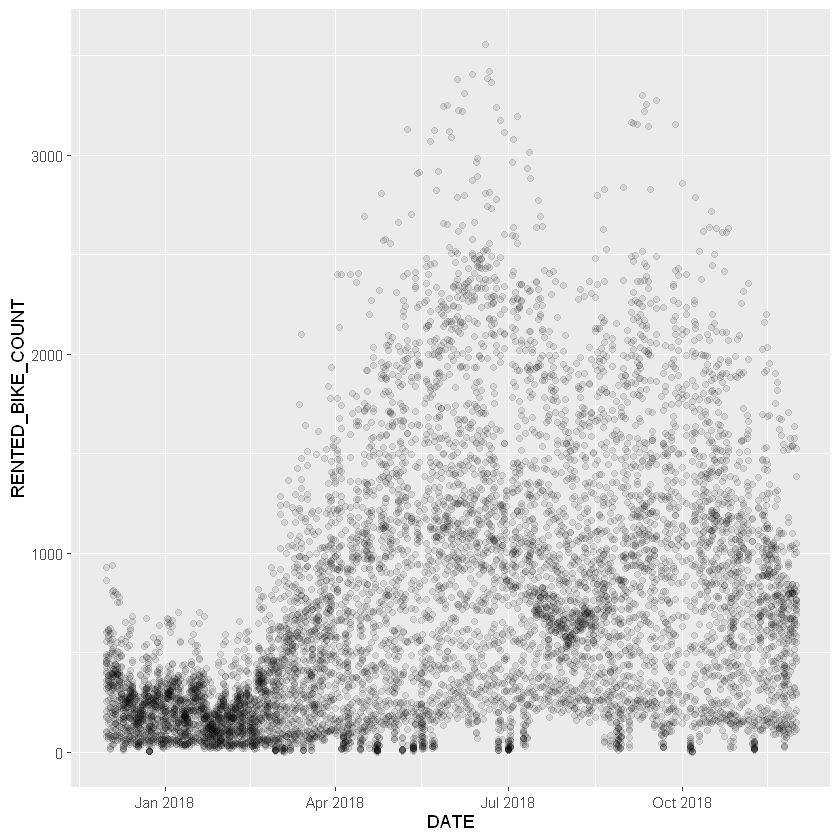

In [80]:
ggplot(seoul_bike_sharing_df, 
       aes(x = DATE, 
           y = RENTED_BIKE_COUNT)) +
    geom_point(alpha = 0.1)

Two patterns jumped out: rentals during winter (especially January–March) are consistently low, while during the warm months counts are much higher and far more spread out.

Adding `HOUR` as colour to the same plot made the daily cycle visible on top of the seasonal one:

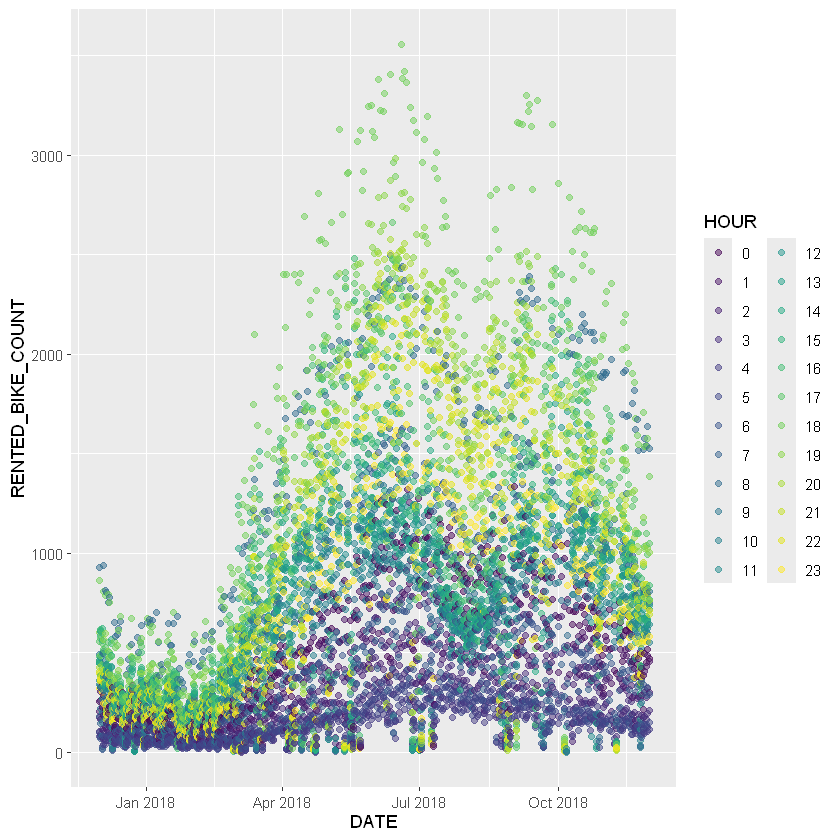

In [81]:
ggplot(seoul_bike_sharing_df, 
       aes(x = DATE, 
           y = RENTED_BIKE_COUNT,
           color = HOUR)) +
    geom_point(alpha = 0.5)

Overnight rentals during the winter were noticeably lower than during the warmer months.

### Distributions

I drew a histogram of `RENTED_BIKE_COUNT` overlaid with a kernel density curve, normalised so the y-axis represents density:

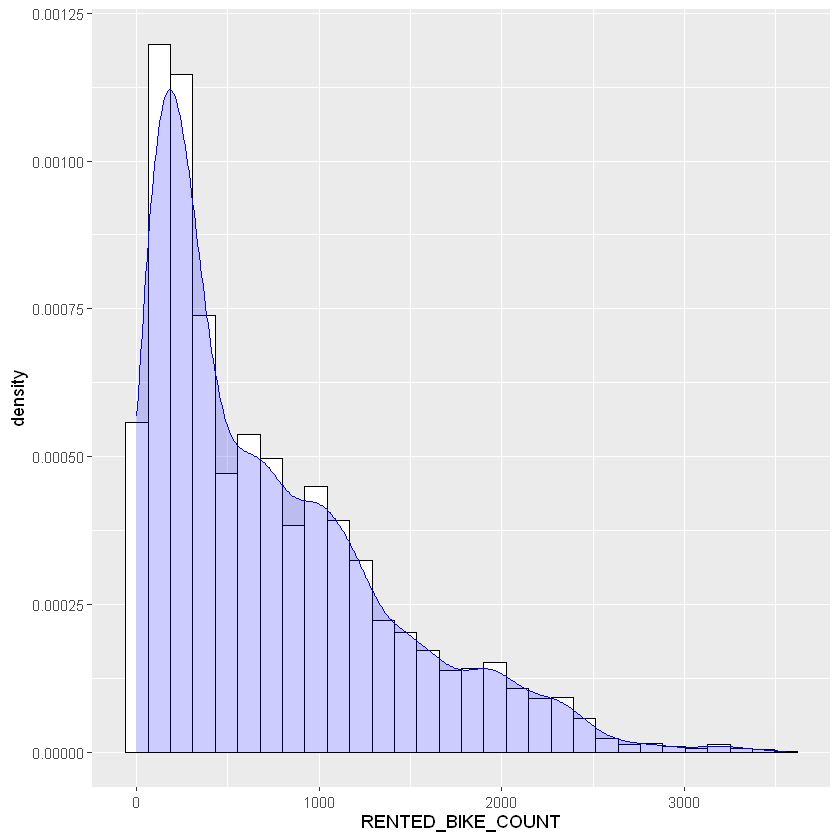

In [83]:
ggplot(seoul_bike_sharing_df,
       aes(x = RENTED_BIKE_COUNT, 
           y = after_stat(density))) +
    geom_histogram(color = "black",
                   fill = "white",
                   bins = 30) +
    geom_density(color = "blue",
                 alpha = 0.2,
                 fill = "blue")

### Correlation between RENTED_BIKE_COUNT and TEMPERATURE

I plotted bike count against temperature, faceted by season and coloured by hour:

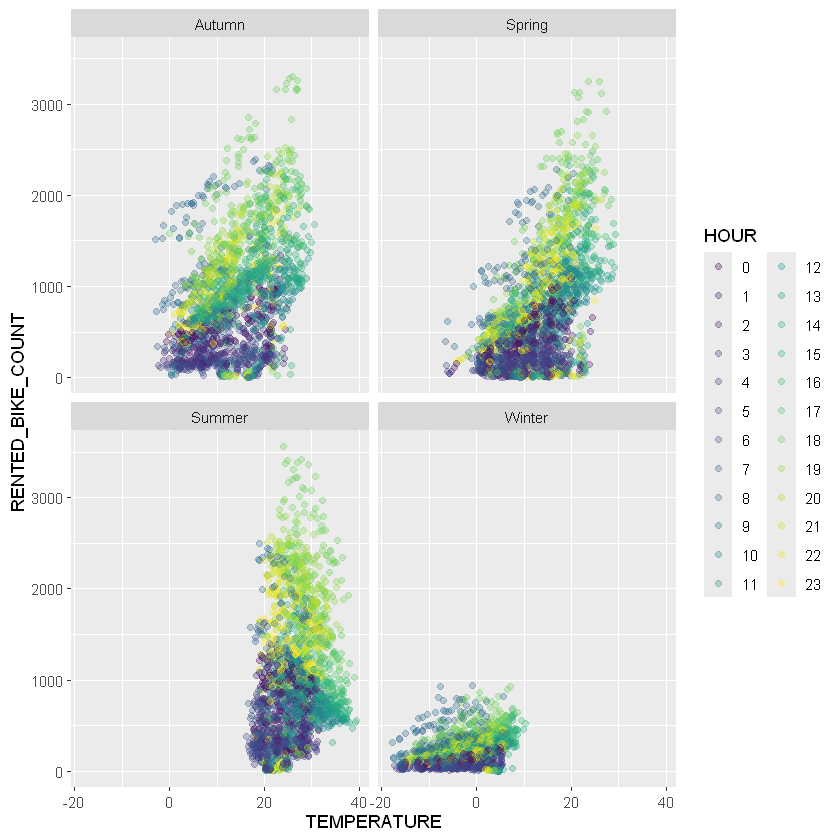

In [84]:
ggplot(seoul_bike_sharing_df, 
       aes(x = TEMPERATURE, 
           y = RENTED_BIKE_COUNT,
           color = HOUR)) +
    geom_point(alpha = 0.3) +
    facet_wrap(~SEASONS)

For comparison, I drew the same plot without the seasonal facets to make the contribution of seasonality obvious:

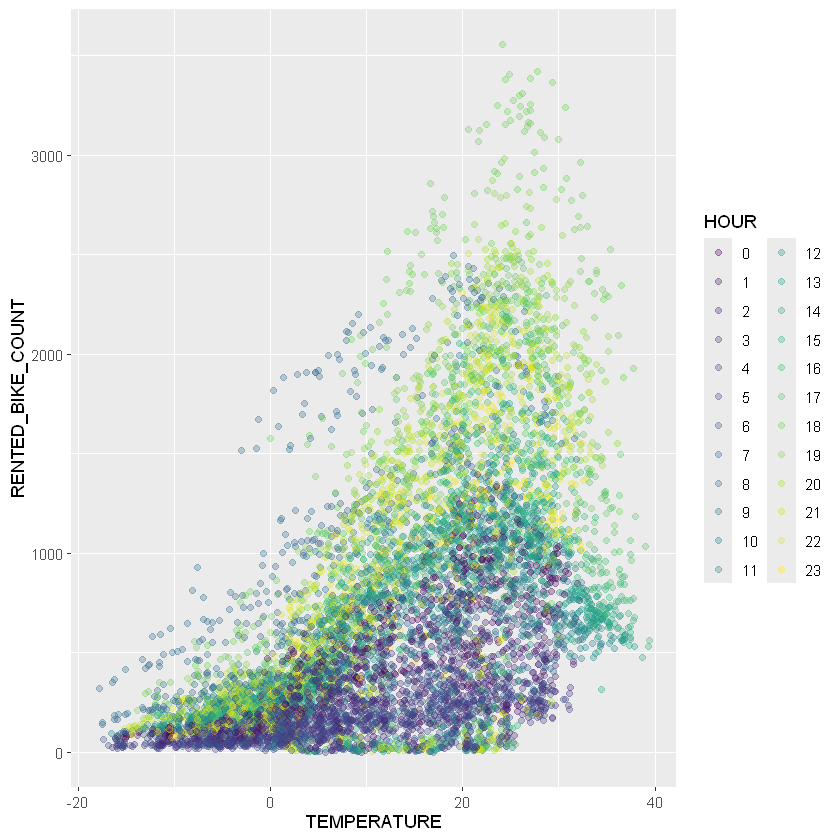

In [85]:
ggplot(seoul_bike_sharing_df, 
       aes(x = TEMPERATURE, 
           y = RENTED_BIKE_COUNT,
           color = HOUR)) +
    geom_point(alpha = 0.3)

### Outliers — boxplots of bike count vs hour, by season

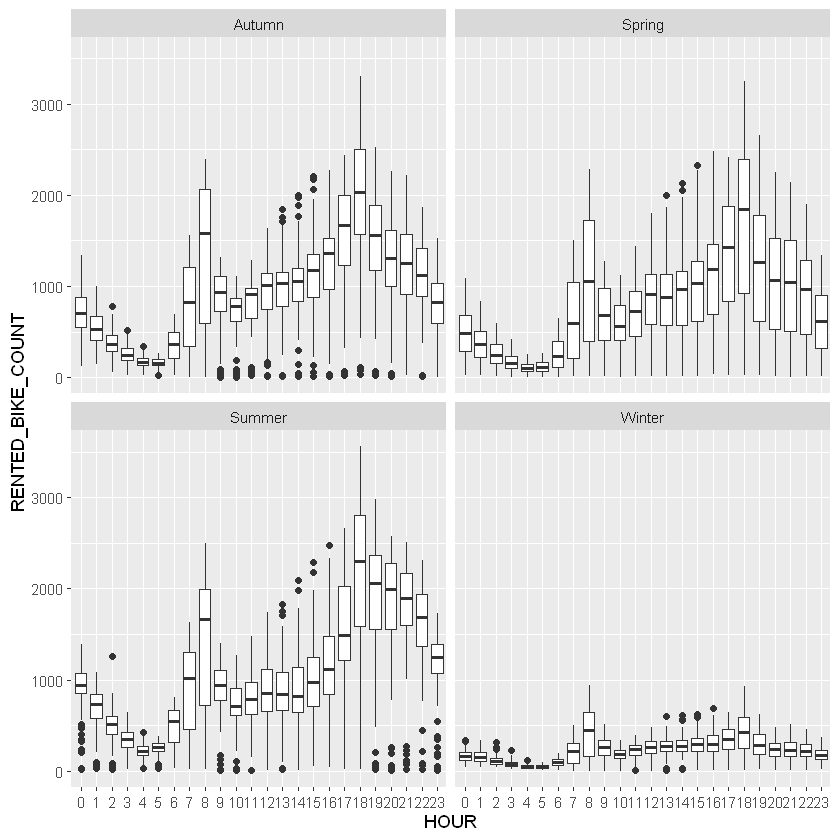

In [86]:
ggplot(seoul_bike_sharing_df, 
       aes(x = HOUR, 
           y = RENTED_BIKE_COUNT)) +
    geom_boxplot() +
    facet_wrap(~SEASONS)

### Daily precipitation

I aggregated rainfall and snowfall by day and plotted them as overlaid lines:

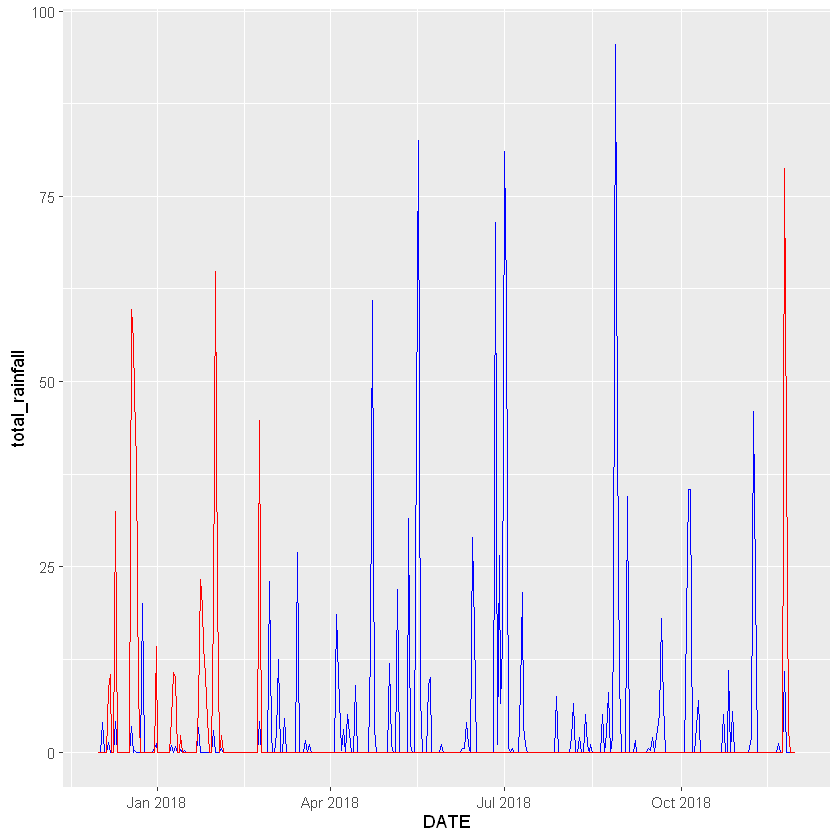

In [87]:
daily_precip <- seoul_bike_sharing_df |>
    group_by(DATE) |>
    summarize(
        total_rainfall = sum(RAINFALL),
        total_snowfall = sum(SNOWFALL))

ggplot(daily_precip, 
       aes(x = DATE)) +
    geom_line(aes(y = total_rainfall), color = "blue") +
    geom_line(aes(y = total_snowfall), color = "red")

And counted how many days had any snowfall:

In [88]:
sum(daily_precip$total_snowfall > 0)

[1] 27

## Part 7 — Baseline linear regression models

With the EDA done, I moved to predictive modelling. The goal was to predict `RENTED_BIKE_COUNT` from the weather and date/time features. I used `tidymodels` for a consistent, pipelined modelling workflow.

I loaded the packages I needed:

In [115]:
library(tidymodels)

I read the normalised, converted Seoul dataset:

In [93]:
bike_sharing_df <- read_csv("seoul_bike_sharing_converted_normalized.csv")
spec(bike_sharing_df)

Rows: 8465 Columns: 41
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): DATE, FUNCTIONING_DAY
dbl (39): RENTED_BIKE_COUNT, TEMPERATURE, HUMIDITY, WIND_SPEED, VISIBILITY, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


cols(
  DATE = col_character(),
  RENTED_BIKE_COUNT = col_double(),
  TEMPERATURE = col_double(),
  HUMIDITY = col_double(),
  WIND_SPEED = col_double(),
  VISIBILITY = col_double(),
  DEW_POINT_TEMPERATURE = col_double(),
  SOLAR_RADIATION = col_double(),
  RAINFALL = col_double(),
  SNOWFALL = col_double(),
  FUNCTIONING_DAY = col_character(),
  `0` = col_double(),
  `1` = col_double(),
  `10` = col_double(),
  `11` = col_double(),
  `12` = col_double(),
  `13` = col_double(),
  `14` = col_double(),
  `15` = col_double(),
  `16` = col_double(),
  `17` = col_double(),
  `18` = col_double(),
  `19` = col_double(),
  `2` = col_double(),
  `20` = col_double(),
  `21` = col_double(),
  `22` = col_double(),
  `23` = col_double(),
  `3` = col_double(),
  `4` = col_double(),
  `5` = col_double(),
  `6` = col_double(),
  `7` = col_double(),
  `8` = col_double(),
  `9` = col_double(),
  AUTUMN = col_double(),
  SPRING = col_double(),
  SUMMER = col_double(),
  WINTER = col_double(),
  HOLIDAY 

I dropped `DATE` and `FUNCTIONING_DAY`. `DATE` as-is acts like a row index. `FUNCTIONING_DAY` collapses to a single value (`YES`) after missing-value processing, so it adds no information.

In [94]:
bike_sharing_df <- bike_sharing_df |> 
                   select(-DATE, -FUNCTIONING_DAY)

### Train/test split

I split the data 75/25 into training and testing sets, with a fixed seed for reproducibility:

In [95]:
# Used the `initial_split()`, `training()`, and `testing()` functions to split the dataset

# With seed 1234 for reproducable results
set.seed(1234)

split <- initial_split(bike_sharing_df, prop = 0.75)

# train_data
train <- training(split)

# test_data
test <- testing(split)

### Linear regression specification

I defined a generic linear-regression spec using the `lm` engine in regression mode:

In [96]:
# Used `linear_reg()` with engine `lm` and mode `regression`
lm_spec <- linear_reg() |> 
    set_engine(engine = "lm") |> 
    set_mode("regression")

### Model 1 — weather variables only

I fit the first model using only the eight weather predictors (`TEMPERATURE`, `HUMIDITY`, `WIND_SPEED`, `VISIBILITY`, `DEW_POINT_TEMPERATURE`, `SOLAR_RADIATION`, `RAINFALL`, `SNOWFALL`):

In [97]:
# Fitted the model called `lm_model_weather`
lm_model_weather  <- lm_spec |> 
    fit(RENTED_BIKE_COUNT ~ TEMPERATURE + 
        HUMIDITY + 
        WIND_SPEED + 
        VISIBILITY + 
        DEW_POINT_TEMPERATURE + 
        SOLAR_RADIATION + 
        RAINFALL + 
        SNOWFALL,
        data = train)

I printed the fit summary:

In [98]:
print(lm_model_weather$fit)


Call:
stats::lm(formula = RENTED_BIKE_COUNT ~ TEMPERATURE + HUMIDITY + 
    WIND_SPEED + VISIBILITY + DEW_POINT_TEMPERATURE + SOLAR_RADIATION + 
    RAINFALL + SNOWFALL, data = data)

Coefficients:
          (Intercept)            TEMPERATURE               HUMIDITY  
               156.71                2399.74                -918.38  
           WIND_SPEED             VISIBILITY  DEW_POINT_TEMPERATURE  
               404.47                  12.56                -316.92  
      SOLAR_RADIATION               RAINFALL               SNOWFALL  
              -444.85               -1764.01                 317.78  



### Model 2 — all variables

I then fit a model with every available predictor (weather + date/time):

In [99]:
# Fitted the model called `lm_model_all`
# `RENTED_BIKE_COUNT ~ .` means use all other variables except for the response variable
lm_model_all  <- lm_spec |> 
    fit(RENTED_BIKE_COUNT ~ . ,
        data = train)

And looked at its summary:

In [100]:
# summary(lm_model_all$fit)
summary(lm_model_all$fit)


Call:
stats::lm(formula = RENTED_BIKE_COUNT ~ ., data = data)

Residuals:
     Min       1Q   Median       3Q      Max 
-1401.45  -218.96    -7.31   199.53  1780.67 

Coefficients: (3 not defined because of singularities)
                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)             212.20      51.04   4.158 3.26e-05 ***
TEMPERATURE             782.66     212.13   3.690 0.000227 ***
HUMIDITY               -886.73      99.49  -8.913  < 2e-16 ***
WIND_SPEED               31.91      40.27   0.792 0.428169    
VISIBILITY               21.87      20.26   1.079 0.280439    
DEW_POINT_TEMPERATURE   598.39     221.37   2.703 0.006888 ** 
SOLAR_RADIATION         276.88      41.47   6.677 2.64e-11 ***
RAINFALL              -2064.64     143.28 -14.410  < 2e-16 ***
SNOWFALL                260.97     103.50   2.522 0.011709 *  
`0`                     -29.30      34.26  -0.855 0.392515    
`1`                    -116.85      33.72  -3.465 0.000533 ***
`10`                 

### Evaluation

I compared the two models using R² and RMSE on the test set. I generated predictions for both models:

In [101]:
# Use predict() function to generate test results for `lm_model_weather` and `lm_model_all`

# test_results_weather for lm_model_weather model
test_results_weather <- lm_model_weather |>
    predict(new_data = test) |>
    mutate(truth = test$RENTED_BIKE_COUNT)

# test_results_all for lm_model_all
test_results_all <- lm_model_all |> 
    predict(new_data = test) |> 
    mutate(truth = test$RENTED_BIKE_COUNT)

Warning message in predict.lm(object = object$fit, newdata = new_data, type = "response", :
"prediction from rank-deficient fit; consider predict(., rankdeficient="NA")"


Then computed the metrics:

In [102]:
# rsq_weather <- rsq(...)
rsq_weather <- rsq(test_results_weather, truth = truth, estimate = .pred)

# rsq_all <- rsq(...)
rsq_all <- rsq(test_results_all, truth = truth, estimate = .pred)

# rmse_weather <- rmse(...)
rmse_weather <- rmse(test_results_weather, truth = truth, estimate = .pred)

# rmse_all <- rmse(...)
rmse_all <- rmse(test_results_all, truth = truth, estimate = .pred)

bind_rows(
    rsq_weather |> 
        mutate(model = "weather"),
    rsq_all |> 
        mutate(model = "all"),
    rmse_weather |> 
        mutate(model = "weather"),
    rmse_all |> 
        mutate(model = "all")
)

.metric,.estimator,.estimate,model
<chr>,<chr>,<dbl>,<chr>
rsq,standard,0.4388660,weather
rsq,standard,0.6690204,all
rmse,standard,474.6247321,weather
rmse,standard,364.4235029,all


The full-variable model (`lm_model_all`) clearly outperformed the weather-only model — using both weather and date/time information gave noticeably better predictions. **However, the "rank-deficient" warning during prediction suggests significant multicollinearity among the predictors, suggesting that some variables in the full model are redundant and could be pruned to create a more stable, simple model.** - With that in the bottom of my mind we march on!

### Identifying the most influential variables

Because all numeric predictors had been normalised to [0, 1], I could directly compare the coefficients to rank variables by importance:

In [103]:
lm_model_all$fit$coefficients

(Intercept)           TEMPERATURE              HUMIDITY 
            212.19946             782.65787            -886.73028 
           WIND_SPEED            VISIBILITY DEW_POINT_TEMPERATURE 
             31.91299              21.87164             598.38726 
      SOLAR_RADIATION              RAINFALL              SNOWFALL 
            276.88165           -2064.63754             260.97330 
                  `0`                   `1`                  `10` 
            -29.29834            -116.84675            -237.51820 
                 `11`                  `12`                  `13` 
           -247.38341            -208.34133            -191.35423 
                 `14`                  `15`                  `16` 
           -192.44168            -109.73364              23.12816 
                 `17`                  `18`                  `19` 
            305.54762             794.80315             522.98821 
                  `2`                  `20`                  `21` 
           -237.21166             431.99524             446.58053 
                 `22`                  `23`                   `3` 
            342.64092             103.80841            -319.87152 
                  `4`                   `5`                   `6` 
           -386.29281            -362.72000            -204.11873 
                  `7`                   `8`                   `9` 
            106.75713             450.97753                    NA 
               AUTUMN                SPRING                SUMMER 
            358.99944             191.36527             198.14201 
               WINTER               HOLIDAY            NO_HOLIDAY 
                   NA            -124.42374                    NA

I sorted them in descending order:

In [104]:
sort(lm_model_all$fit$coefficients, decreasing = TRUE)

`18`           TEMPERATURE DEW_POINT_TEMPERATURE 
            794.80315             782.65787             598.38726 
                 `19`                   `8`                  `21` 
            522.98821             450.97753             446.58053 
                 `20`                AUTUMN                  `22` 
            431.99524             358.99944             342.64092 
                 `17`       SOLAR_RADIATION              SNOWFALL 
            305.54762             276.88165             260.97330 
          (Intercept)                SUMMER                SPRING 
            212.19946             198.14201             191.36527 
                  `7`                  `23`            WIND_SPEED 
            106.75713             103.80841              31.91299 
                 `16`            VISIBILITY                   `0` 
             23.12816              21.87164             -29.29834 
                 `15`                   `1`               HOLIDAY 
           -109.73364            -116.84675            -124.42374 
                 `13`                  `14`                   `6` 
           -191.35423            -192.44168            -204.11873 
                 `12`                   `2`                  `10` 
           -208.34133            -237.21166            -237.51820 
                 `11`                   `3`                   `5` 
           -247.38341            -319.87152            -362.72000 
                  `4`              HUMIDITY              RAINFALL 
           -386.29281            -886.73028           -2064.63754

And visualised the absolute coefficients with a horizontal bar chart so I could quickly read off which predictors carry the most weight:

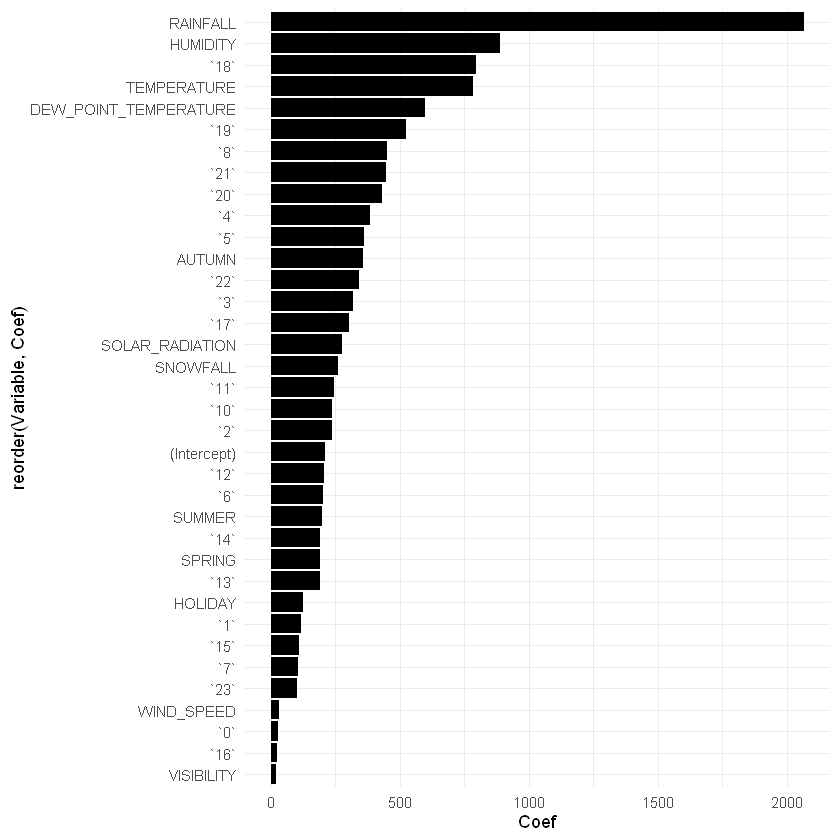

In [117]:
# Visualize the list using ggplot and geom_bar
coef_df <- data.frame(variable = names(lm_model_all$fit$coefficients),
                      coefficient = as.numeric(lm_model_all$fit$coefficients))

coef_df <- coef_df |> dplyr::filter(!is.na(coefficient))

coef_df$abs_coefficient <- abs(coef_df$coefficient)

ggplot(coef_df, aes(x = reorder(variable, abs_coefficient), y = abs_coefficient)) +
    geom_bar(stat = "identity", fill = "black") +
    coord_flip() +
    labs(x = "reorder(Variable, Coef)", 
         y = "Coef") +
    theme_minimal()

## Part 8 — Refining the baseline regression models

The baseline gave reasonable RMSE and R², but linear models can only capture linear relationships, and the predictors interact in non-trivial ways. 

As shown in the coefficients plot, `RAINFALL`, `HUMIDITY`, and `TEMPERATURE` emerged as the primary drivers of bike rentals.

To truly improve the results and handle the "rank-deficient" issues found earlier, I refined the model in three deeper directions:
* **Polynomial terms**: To capture non-linear relationships, like how demand might peak at a certain temperature then drop off.
* **Interaction terms**: To capture combined effects, such as how the impact of humidity changes depending on the heat.
* **Regularization (glmnet)**: To control overfitting and automatically handle the multicollinearity (redundant variables) we identified in the full model.

After running five experiments with these refined settings, I was able to identify the most effective model for the final results.

### Polynomial terms

Looking at the bike-count vs temperature scatter, the relationship is clearly not linear:

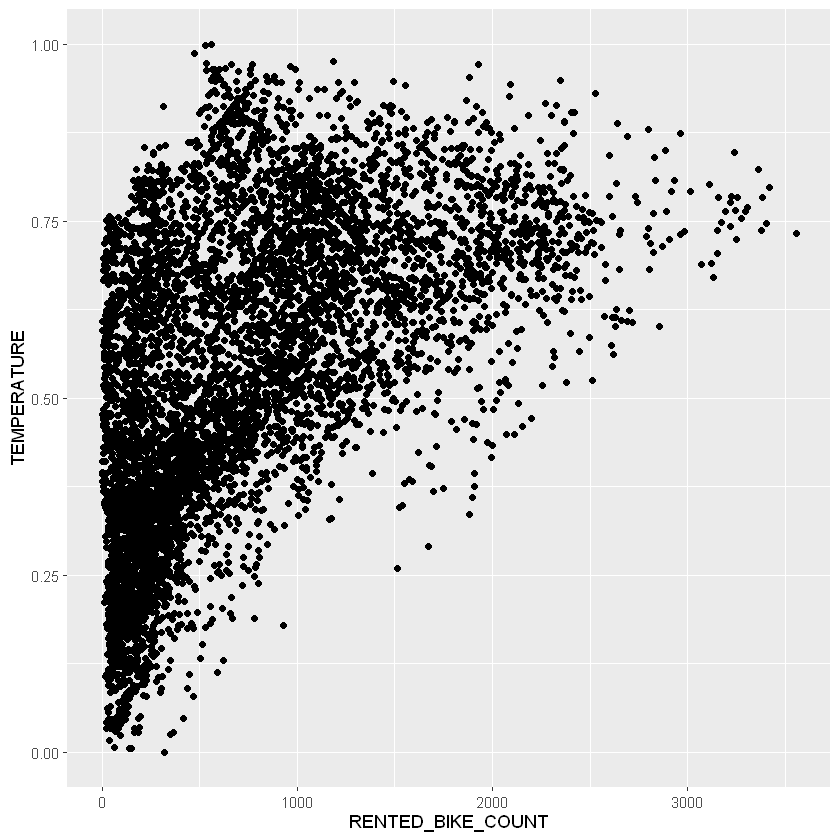

In [124]:
ggplot(data = train_data, aes(RENTED_BIKE_COUNT, TEMPERATURE)) + 
    geom_point() 

I overlaid linear, quadratic, quartic, and sextic fits of `RENTED_BIKE_COUNT` on `HUMIDITY` to see how higher-order polynomials track the data:

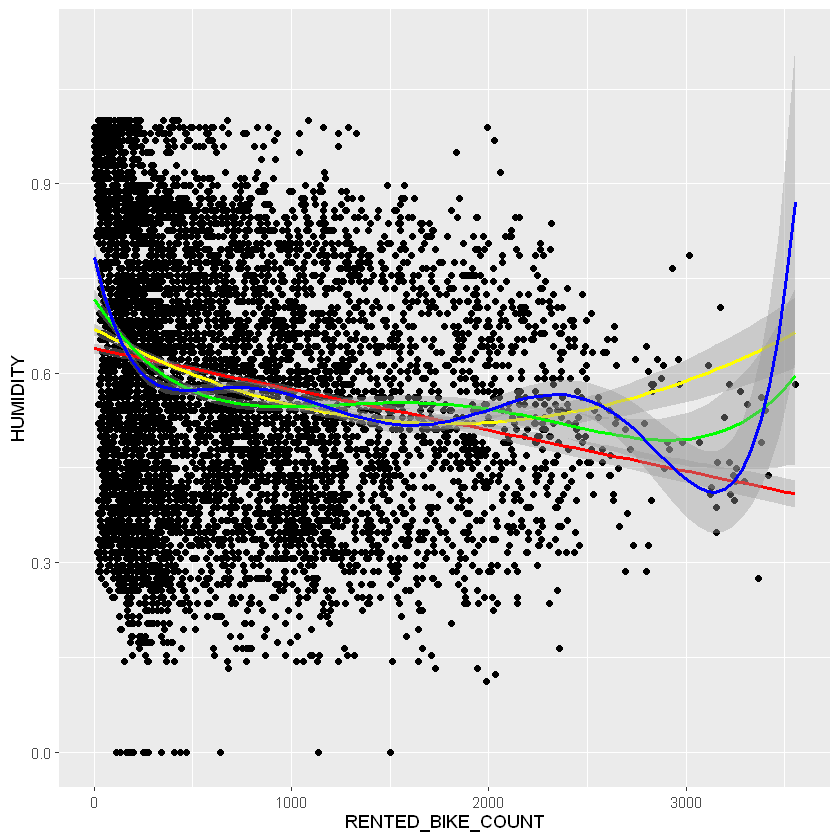

In [125]:
ggplot(data=train_data, aes(RENTED_BIKE_COUNT, HUMIDITY)) + 
    geom_point() + 
    geom_smooth(method = "lm", formula = y ~ x, color="red") + 
    geom_smooth(method = "lm", formula = y ~ poly(x, 2), color="yellow") + 
    geom_smooth(method = "lm", formula = y ~ poly(x, 4), color="green") + 
    geom_smooth(method = "lm", formula = y ~ poly(x, 6), color="blue")

Then I fit a polynomial regression on the most important variables I'd identified earlier — `TEMPERATURE` (degree 6), `HUMIDITY` (degree 4), and `RAINFALL`:

In [126]:
lm_poly <- lm_spec |> 
    fit(RENTED_BIKE_COUNT ~ poly(TEMPERATURE, 6) + 
                            poly(HUMIDITY, 4) + 
                            RAINFALL,
        data = train_data) 

Model summary:

In [127]:
summary(lm_poly$fit)


Call:
stats::lm(formula = RENTED_BIKE_COUNT ~ poly(TEMPERATURE, 6) + 
    poly(HUMIDITY, 4) + RAINFALL, data = data)

Residuals:
     Min       1Q   Median       3Q      Max 
-1250.34  -273.56   -64.57   197.41  2233.21 

Coefficients:
                        Estimate Std. Error t value Pr(>|t|)    
(Intercept)              738.950      5.686 129.953  < 2e-16 ***
poly(TEMPERATURE, 6)1  32324.773    473.381  68.285  < 2e-16 ***
poly(TEMPERATURE, 6)2  -6669.846    482.813 -13.815  < 2e-16 ***
poly(TEMPERATURE, 6)3  -9613.720    465.400 -20.657  < 2e-16 ***
poly(TEMPERATURE, 6)4  -2931.452    465.083  -6.303 3.10e-10 ***
poly(TEMPERATURE, 6)5   -500.272    467.304  -1.071 0.284410    
poly(TEMPERATURE, 6)6    732.593    468.625   1.563 0.118033    
poly(HUMIDITY, 4)1    -17609.224    499.471 -35.256  < 2e-16 ***
poly(HUMIDITY, 4)2     -9533.546    490.605 -19.432  < 2e-16 ***
poly(HUMIDITY, 4)3       154.398    482.979   0.320 0.749221    
poly(HUMIDITY, 4)4     -1837.972    476.744  -3.

Predictions on the test set:

In [128]:
test_results_poly <- lm_poly |>
    predict(new_data = test_data) |>
    mutate(truth = test_data$RENTED_BIKE_COUNT)

Since a negative rented-bike count is impossible, I clipped any negative predictions to zero:

In [129]:
test_results_poly <- test_results_poly |>
    mutate(.pred = ifelse(.pred < 0, 0, .pred))

Then computed R² and RMSE:

In [130]:
rsq_poly <- rsq(test_results_poly, truth = truth, estimate = .pred)

rmse_poly <- rmse(test_results_poly, truth = truth, estimate = .pred)

bind_rows(rsq_poly, rmse_poly)

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rsq,standard,0.4903101
rmse,standard,452.0658699


### Interaction terms

I added interaction terms on top of the polynomial baseline, using the `*` operator to multiply `TEMPERATURE`, `HUMIDITY`, and `RAINFALL`:

In [131]:
lm_weather_interaction <- lm_spec |> 
    fit(RENTED_BIKE_COUNT ~ TEMPERATURE * 
                            HUMIDITY *
                            RAINFALL,
        data = train_data) 

In [132]:
# Print model summary
summary(lm_weather_interaction$fit)


Call:
stats::lm(formula = RENTED_BIKE_COUNT ~ TEMPERATURE * HUMIDITY * 
    RAINFALL, data = data)

Residuals:
     Min       1Q   Median       3Q      Max 
-1410.64  -287.12   -81.22   180.09  2438.38 

Coefficients:
                               Estimate Std. Error t value Pr(>|t|)    
(Intercept)                     -208.41      48.43  -4.303 1.71e-05 ***
TEMPERATURE                     2749.07      88.56  31.042  < 2e-16 ***
HUMIDITY                          23.29      88.26   0.264    0.792    
RAINFALL                        8793.05   35719.55   0.246    0.806    
TEMPERATURE:HUMIDITY           -1645.93     157.31 -10.463  < 2e-16 ***
TEMPERATURE:RAINFALL          -87827.88   56642.39  -1.551    0.121    
HUMIDITY:RAINFALL             -10706.08   37152.39  -0.288    0.773    
TEMPERATURE:HUMIDITY:RAINFALL  89295.96   58615.23   1.523    0.128    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 489.1 on 6764 degrees of freedom
Multipl

And evaluated:

In [133]:
test_results_weather_interaction <- lm_weather_interaction |>
    predict(new_data = test_data) |>
    mutate(truth = test_data$RENTED_BIKE_COUNT)

rsq_weather_interaction <- rsq(test_results_weather_interaction, truth = truth, estimate = .pred)

rmse_weather_interaction <- rmse(test_results_weather_interaction, truth = truth, estimate = .pred)

bind_rows(rsq_weather_interaction, rmse_weather_interaction)

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rsq,standard,0.4402162
rmse,standard,473.6667239


### Regularisation with glmnet

Polynomial and interaction terms make the model more flexible but also more prone to overfitting, and they tend to amplify collinearity between predictors. To address both, I switched the engine from `lm` to `glmnet`, which supports Lasso (L1), Ridge (L2), and Elastic Net regularisation through the `penalty` and `mixture` parameters.

I defined the spec with both parameters marked for tuning:

In [134]:
glmnet_spec <- linear_reg(penalty = tune(),
                          mixture = tune()) |>
    set_engine("glmnet") |> 
    set_mode("regression")

Wrapped it in a workflow with the full-variable formula:

In [135]:
glmnet_wf <- workflow() |> 
    add_model(glmnet_spec) |>
    add_formula(RENTED_BIKE_COUNT ~ . )

Built a regular grid over `penalty` (log10 scale, -4 to 0) and `mixture` (0 to 1):

In [136]:
glmnet_grid <- grid_regular(penalty(range = c(-4, 0),
                                    trans = log10_trans()),
                            mixture(range = c(0, 1)),
                            levels = 5)

Set up 5-fold cross-validation on the training data:

In [137]:
cv_folds <- vfold_cv(train_data, v = 5)

And ran the grid search:

In [138]:
glmnet_results <- tune_grid(glmnet_wf, 
                            resamples = cv_folds, 
                            grid = glmnet_grid, 
                            metrics = metric_set(rmse, rsq))

Top configurations by RMSE:

In [139]:
show_best(glmnet_results, metric = "rmse")

penalty,mixture,.metric,.estimator,mean,n,std_err,.config
<dbl>,<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
1e-04,0.25,rmse,standard,378.3706,5,7.283111,pre0_mod02_post0
1e-03,0.25,rmse,standard,378.3706,5,7.283111,pre0_mod07_post0
1e-02,0.25,rmse,standard,378.3706,5,7.283111,pre0_mod12_post0
1e-01,0.25,rmse,standard,378.3706,5,7.283111,pre0_mod17_post0
1e+00,0.25,rmse,standard,378.3706,5,7.283111,pre0_mod22_post0


Best parameter combination:

In [140]:
best_params <- select_best(glmnet_results, metric = "rmse")
best_params

penalty,mixture,.config
<dbl>,<dbl>,<chr>
1e-04,0.25,pre0_mod02_post0


I installed and loaded `glmnet`:

In [142]:
library('glmnet')

Loading required package: Matrix

Warning message:
"package 'Matrix' was built under R version 4.5.3"

Attaching package: 'Matrix'


The following objects are masked from 'package:tidyr':

    expand, pack, unpack


Loaded glmnet 4.1-10



Finalised the workflow with the chosen parameters and fit the model on the training data:

In [143]:
final_glmnet_wf <- finalize_workflow(glmnet_wf, best_params)

final_glmnet_fit <- final_glmnet_wf |>
  fit(data = train_data)

And evaluated on the test set:

In [144]:
test_results_glmnet <- final_glmnet_fit |>
  predict(new_data = test_data) |>
  bind_cols(test_data |> select(RENTED_BIKE_COUNT)) |>
  rename(truth = RENTED_BIKE_COUNT)

rsq_glmnet <- rsq(test_results_glmnet, truth = truth, estimate = .pred)
rmse_glmnet <- rmse(test_results_glmnet, truth = truth, estimate = .pred)

bind_rows(rsq_glmnet, rmse_glmnet)

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rsq,standard,0.6692189
rmse,standard,364.0401902


### Searching for the best model — five experiments

I ran five different glmnet specifications, each combining polynomial terms, interaction terms, and regularisation in different ways, and picked the one with the lowest RMSE on the test set.

**Model 1** — Weather-only polynomials with glmnet, no hour dummies:

In [145]:
# Model 1: Weather Polynomials + GLMNet (no hour dummies)
glmnet_poly_spec <- linear_reg(penalty = tune(),
                                        mixture = tune()) |> 
    set_engine("glmnet") |> 
    set_mode("regression")

glmnet_poly_wf <- workflow() |> 
    add_model(glmnet_poly_spec) |>
    add_formula(RENTED_BIKE_COUNT ~ poly(TEMPERATURE, 6) + 
                            poly(HUMIDITY, 4) + 
                            RAINFALL)

glmnet_poly_results <- tune_grid(glmnet_poly_wf, 
                            resamples = cv_folds, 
                            grid = glmnet_grid, 
                            metrics = metric_set(rmse, rsq))

best_poly_params <- select_best(glmnet_poly_results, metric = "rmse")

final_glmnet_poly_wf <- finalize_workflow(glmnet_poly_wf, best_poly_params)

final_glmnet_poly_fit <- final_glmnet_poly_wf |>
  fit(data = train_data)

test_results_glmnet_poly <- final_glmnet_poly_fit |>
  predict(new_data = test_data) |>
  bind_cols(test_data |> select(RENTED_BIKE_COUNT)) |>
  rename(truth = RENTED_BIKE_COUNT)

rsq_glmnet_poly <- rsq(test_results_glmnet_poly, truth = truth, estimate = .pred)
rmse_glmnet_poly <- rmse(test_results_glmnet_poly, truth = truth, estimate = .pred)

bind_rows(rsq_glmnet_poly, rmse_glmnet_poly)

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rsq,standard,0.4815713
rmse,standard,455.7181323


**Model 2** — Season × temperature interactions with glmnet:

In [146]:
# Model 2 Season-temperature interactions + glmnet
glmnet_season_interact_spec <- linear_reg(penalty = tune(),
                                          mixture = tune()) |>
  set_engine("glmnet") |>
  set_mode("regression")

glmnet_season_interact_wf <- workflow() |>
  add_model(glmnet_season_interact_spec) |>
  add_formula(RENTED_BIKE_COUNT ~ . +
                poly(TEMPERATURE, 3) +
                poly(SOLAR_RADIATION, 3) +
                TEMPERATURE * SUMMER +
                TEMPERATURE * WINTER)

glmnet_season_interact_results <- tune_grid(glmnet_season_interact_wf,
                                            resamples = cv_folds,
                                            grid     = glmnet_grid,
                                            metrics  = metric_set(rmse, rsq))

best_season_interact_params <- select_best(glmnet_season_interact_results,
                                           metric = "rmse")

final_glmnet_season_interact_wf  <- finalize_workflow(glmnet_season_interact_wf,
                                                      best_season_interact_params)
final_glmnet_season_interact_fit <- final_glmnet_season_interact_wf |>
  fit(data = train_data)

test_results_glmnet_season_interact <- final_glmnet_season_interact_fit |>
  predict(new_data = test_data) |>
  bind_cols(test_data |> select(RENTED_BIKE_COUNT)) |>
  rename(truth = RENTED_BIKE_COUNT)

rsq_glmnet_season_interact  <- rsq(test_results_glmnet_season_interact,
                                   truth = truth, estimate = .pred)
rmse_glmnet_season_interact <- rmse(test_results_glmnet_season_interact,
                                    truth = truth, estimate = .pred)
bind_rows(rsq_glmnet_season_interact, rmse_glmnet_season_interact)

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rsq,standard,0.7027019
rmse,standard,345.1422783


**Model 3** — Full features + polynomials with glmnet:

In [147]:
# Model 3: Full Features + Polynomials + GLMNet
glmnet_full_poly_spec <- linear_reg(penalty = tune(), mixture = tune()) |>
  set_engine("glmnet") |> set_mode("regression")

glmnet_full_poly_wf <- workflow() |>
  add_model(glmnet_full_poly_spec) |>
  add_formula(RENTED_BIKE_COUNT ~ . + poly(TEMPERATURE, 3) + poly(SOLAR_RADIATION, 3))

glmnet_full_poly_tune <- tune_grid(glmnet_full_poly_wf,
                                   resamples = cv_folds,
                                   grid = glmnet_grid,
                                   metrics = metric_set(rmse, rsq))

glmnet_full_poly_best <- select_best(glmnet_full_poly_tune, metric = "rmse")

glmnet_full_poly_fit <- finalize_workflow(glmnet_full_poly_wf, glmnet_full_poly_best) |>
  fit(data = train_data)

test_results_glmnet_full_poly <- glmnet_full_poly_fit |>
  predict(new_data = test_data) |>
  bind_cols(test_data |> select(RENTED_BIKE_COUNT)) |>
  rename(truth = RENTED_BIKE_COUNT)

rsq_glmnet_full_poly <- rsq(test_results_glmnet_full_poly, truth = truth, estimate = .pred)
rmse_glmnet_full_poly <- rmse(test_results_glmnet_full_poly, truth = truth, estimate = .pred)
bind_rows(rsq_glmnet_full_poly, rmse_glmnet_full_poly)

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rsq,standard,0.7031302
rmse,standard,344.8883573


**Model 4** — Weather × weather interactions with glmnet:

In [148]:
# Model 4 Weather interactions + glmnet
glmnet_weather_interact_spec <- linear_reg(penalty = tune(),
                                           mixture = tune()) |>
  set_engine("glmnet") |>
  set_mode("regression")

glmnet_weather_interact_wf <- workflow() |>
  add_model(glmnet_weather_interact_spec) |>
  add_formula(RENTED_BIKE_COUNT ~ . +
                poly(TEMPERATURE, 3) +
                poly(SOLAR_RADIATION, 3) +
                TEMPERATURE * HUMIDITY +
                TEMPERATURE * SOLAR_RADIATION)

glmnet_weather_interact_results <- tune_grid(glmnet_weather_interact_wf,
                                             resamples = cv_folds,
                                             grid     = glmnet_grid,
                                             metrics  = metric_set(rmse, rsq))

best_weather_interact_params <- select_best(glmnet_weather_interact_results,
                                            metric = "rmse")

final_glmnet_weather_interact_wf  <- finalize_workflow(glmnet_weather_interact_wf,
                                                       best_weather_interact_params)
final_glmnet_weather_interact_fit <- final_glmnet_weather_interact_wf |>
  fit(data = train_data)

test_results_glmnet_weather_interact <- final_glmnet_weather_interact_fit |>
  predict(new_data = test_data) |>
  bind_cols(test_data |> select(RENTED_BIKE_COUNT)) |>
  rename(truth = RENTED_BIKE_COUNT)

rsq_glmnet_weather_interact  <- rsq(test_results_glmnet_weather_interact,
                                    truth = truth, estimate = .pred)
rmse_glmnet_weather_interact <- rmse(test_results_glmnet_weather_interact,
                                     truth = truth, estimate = .pred)
bind_rows(rsq_glmnet_weather_interact, rmse_glmnet_weather_interact)

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rsq,standard,0.7337512
rmse,standard,326.6811580


**Model 5** — Curated polynomials and interactions with glmnet:

In [149]:
# Model 5 Curated poly + interactions, WITH hour dummies
glmnet_curated_spec <- linear_reg(penalty = tune(),
                                  mixture = tune()) |>
  set_engine("glmnet") |>
  set_mode("regression")

glmnet_curated_wf <- workflow() |>
  add_model(glmnet_curated_spec) |>
  add_formula(RENTED_BIKE_COUNT ~ . +
                poly(TEMPERATURE, 3) +
                poly(HUMIDITY, 3) +
                poly(DEW_POINT_TEMPERATURE, 3) +
                poly(SOLAR_RADIATION, 3) +
                TEMPERATURE * SUMMER +
                TEMPERATURE * WINTER +
                TEMPERATURE * HUMIDITY)

glmnet_curated_results <- tune_grid(glmnet_curated_wf,
                                    resamples = cv_folds,
                                    grid     = glmnet_grid,
                                    metrics  = metric_set(rmse, rsq))

best_curated_params <- select_best(glmnet_curated_results, metric = "rmse")

final_glmnet_curated_wf  <- finalize_workflow(glmnet_curated_wf, best_curated_params)
final_glmnet_curated_fit <- final_glmnet_curated_wf |>
  fit(data = train_data)

test_results_glmnet_curated <- final_glmnet_curated_fit |>
  predict(new_data = test_data) |>
  bind_cols(test_data |> select(RENTED_BIKE_COUNT)) |>
  rename(truth = RENTED_BIKE_COUNT)

rsq_glmnet_curated  <- rsq(test_results_glmnet_curated,
                            truth = truth, estimate = .pred)
rmse_glmnet_curated <- rmse(test_results_glmnet_curated,
                             truth = truth, estimate = .pred)
bind_rows(rsq_glmnet_curated, rmse_glmnet_curated)

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rsq,standard,0.7368453
rmse,standard,324.7247369


I collected the RMSE and R² for all five models, identified the best by lowest RMSE, and printed the comparison:

In [150]:
# Report the best performed model in terms of rmse and rsq
model_metrics <- tibble(
  Model = c("M1: GLMNet Poly\n(weather only)",
            "M2: GLMNet Season\nInteract",
            "M3: GLMNet Full\nPoly",
            "M4: GLMNet Weather\nInteract",
            "M5: GLMNet Curated"),
  RMSE = c(rmse_glmnet_poly$.estimate,
           rmse_glmnet_season_interact$.estimate,
           rmse_glmnet_full_poly$.estimate,
           rmse_glmnet_weather_interact$.estimate,
           rmse_glmnet_curated$.estimate),
  RSQ  = c(rsq_glmnet_poly$.estimate,
           rsq_glmnet_season_interact$.estimate,
           rsq_glmnet_full_poly$.estimate,
           rsq_glmnet_weather_interact$.estimate,
           rsq_glmnet_curated$.estimate)
)

# Identify and print best model
best_model <- model_metrics |> slice_min(RMSE, n = 1)

cat("=== All Models ===\n")
print(model_metrics)
cat("\n=== Best Model (lowest RMSE) ===\n")
print(best_model)

=== All Models ===
# A tibble: 5 × 3
  Model                              RMSE   RSQ
  <chr>                             <dbl> <dbl>
1 "M1: GLMNet Poly\n(weather only)"  456. 0.482
2 "M2: GLMNet Season\nInteract"      345. 0.703
3 "M3: GLMNet Full\nPoly"            345. 0.703
4 "M4: GLMNet Weather\nInteract"     327. 0.734
5 "M5: GLMNet Curated"               325. 0.737

=== Best Model (lowest RMSE) ===
# A tibble: 1 × 3
  Model               RMSE   RSQ
  <chr>              <dbl> <dbl>
1 M5: GLMNet Curated  325. 0.737


### Visualising model comparison and Q-Q calibration

I plotted RMSE and R² for the five models side by side. Since the two metrics live on very different scales, I used `facet_wrap` with free y-axes:

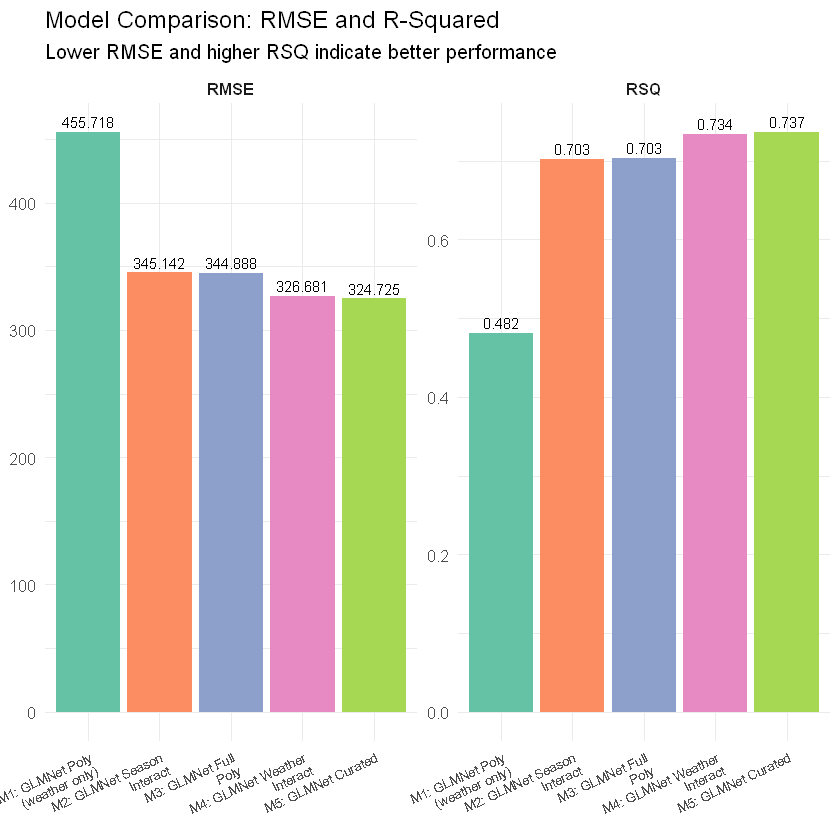

In [151]:
model_metrics_long <- model_metrics |>
  pivot_longer(cols = c(RMSE, RSQ),
               names_to  = "Metric",
               values_to = "Value")

ggplot(model_metrics_long, aes(x = Model, y = Value, fill = Model)) +
  geom_bar(stat = "identity") +
  # Separate panels per metric — essential since RMSE (~300-450) and
  # RSQ (~0.5-0.75) live on completely different scales
  facet_wrap(~ Metric, scales = "free_y") +
  geom_text(aes(label = round(Value, 3)),
            vjust = -0.4, size = 3.2) +
  scale_fill_brewer(palette = "Set2") +
  labs(title    = "Model Comparison: RMSE and R-Squared",
       subtitle = "Lower RMSE and higher RSQ indicate better performance",
       x = NULL, y = NULL, fill = "Model") +
  theme_minimal(base_size = 12) +
  theme(axis.text.x  = element_text(angle = 25, hjust = 1, size = 8),
        strip.text    = element_text(face = "bold"),
        legend.position = "none")

Finally, I produced a Q-Q plot of the best model's predictions against the true values on the test set — points hugging the line indicate a well-calibrated model:

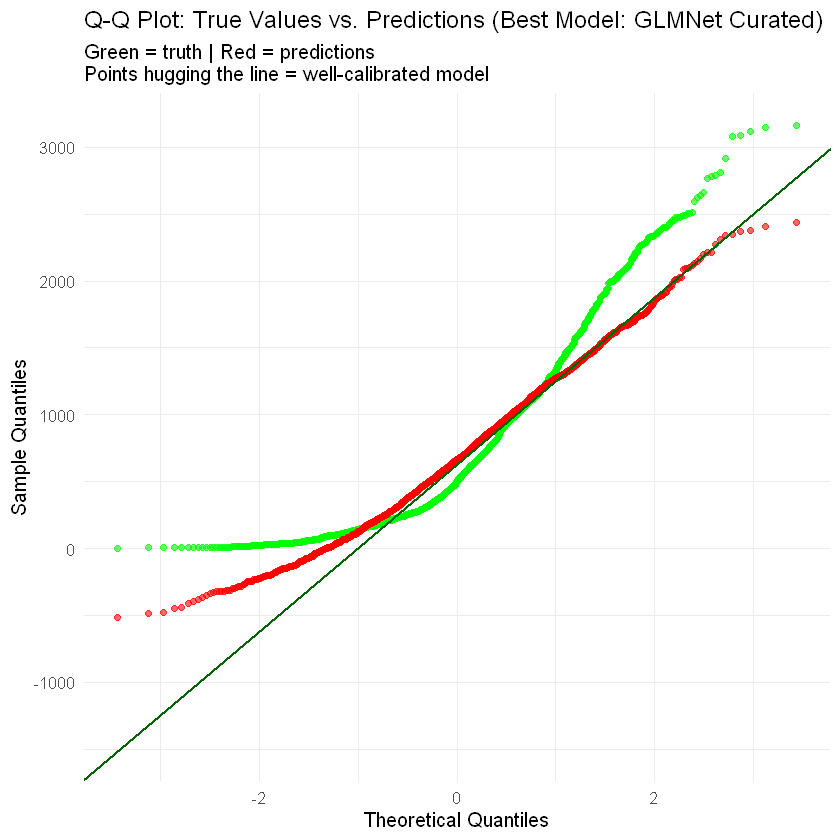

In [152]:
best_results <- test_results_glmnet_curated |>
  rename(prediction = .pred)

ggplot(best_results) +
  stat_qq(aes(sample = truth),      color = "green", alpha = 0.6) +
  stat_qq(aes(sample = prediction), color = "red",   alpha = 0.6) +
  stat_qq_line(aes(sample = truth), color = "darkgreen", linewidth = 0.7) +
  labs(title    = "Q-Q Plot: True Values vs. Predictions (Best Model: GLMNet Curated)",
       subtitle = "Green = truth | Red = predictions\nPoints hugging the line = well-calibrated model",
       x = "Theoretical Quantiles",
       y = "Sample Quantiles") +
  theme_minimal(base_size = 12)

## Wrap-up

Starting from a Wikipedia scrape and a few API calls, I built up a clean, normalised hourly bike-sharing dataset for Seoul, explored it with both SQL and ggplot2, and then trained a sequence of linear models — from a weather-only baseline through polynomial and interaction extensions to regularised glmnet models tuned with cross-validated grid search. The best of the five refined models, judged by RMSE on the held-out test set, is the one I'd carry forward into any downstream dashboarding or comparison work across cities with comparable fleet sizes.